# Credit Scoring Model

## CodeAlpha Machine Learning Internship - Task 1

### Objective
Predict the creditworthiness of individuals using historical financial and credit-related data.

### Machine Learning Approach
- Data Cleaning
- Exploratory Data Analysis
- Feature Engineering
- Classification
- Model Evaluation
- Model Comparison

In [7]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

import joblib

print("All libraries imported successfully!")

All libraries imported successfully!


In [8]:
file_path = "../data/default_of_credit_card_clients.xls"

df = pd.read_excel(file_path, header=1)

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [9]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 30000
Number of columns: 25


In [10]:
display(df.head())

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [11]:
display(df.tail())

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
29995,29996,220000,1,3,1,39,0,0,0,0,...,88004,31237,15980,8500,20000,5003,3047,5000,1000,0
29996,29997,150000,1,3,2,43,-1,-1,-1,-1,...,8979,5190,0,1837,3526,8998,129,0,0,0
29997,29998,30000,1,2,2,37,4,3,2,-1,...,20878,20582,19357,0,0,22000,4200,2000,3100,1
29998,29999,80000,1,3,1,41,1,-1,0,0,...,52774,11855,48944,85900,3409,1178,1926,52964,1804,1
29999,30000,50000,1,2,1,46,0,0,0,0,...,36535,32428,15313,2078,1800,1430,1000,1000,1000,1


In [12]:
print("Dataset Columns:\n")

for i, column in enumerate(df.columns, 1):
    print(f"{i}. {column}")

Dataset Columns:

1. ID
2. LIMIT_BAL
3. SEX
4. EDUCATION
5. MARRIAGE
6. AGE
7. PAY_0
8. PAY_2
9. PAY_3
10. PAY_4
11. PAY_5
12. PAY_6
13. BILL_AMT1
14. BILL_AMT2
15. BILL_AMT3
16. BILL_AMT4
17. BILL_AMT5
18. BILL_AMT6
19. PAY_AMT1
20. PAY_AMT2
21. PAY_AMT3
22. PAY_AMT4
23. PAY_AMT5
24. PAY_AMT6
25. default payment next month


In [13]:
print(df.dtypes)

ID                            int64
LIMIT_BAL                     int64
SEX                           int64
EDUCATION                     int64
MARRIAGE                      int64
AGE                           int64
PAY_0                         int64
PAY_2                         int64
PAY_3                         int64
PAY_4                         int64
PAY_5                         int64
PAY_6                         int64
BILL_AMT1                     int64
BILL_AMT2                     int64
BILL_AMT3                     int64
BILL_AMT4                     int64
BILL_AMT5                     int64
BILL_AMT6                     int64
PAY_AMT1                      int64
PAY_AMT2                      int64
PAY_AMT3                      int64
PAY_AMT4                      int64
PAY_AMT5                      int64
PAY_AMT6                      int64
default payment next month    int64
dtype: object


In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          30000 non-null  int64
 1   LIMIT_BAL                   30000 non-null  int64
 2   SEX                         30000 non-null  int64
 3   EDUCATION                   30000 non-null  int64
 4   MARRIAGE                    30000 non-null  int64
 5   AGE                         30000 non-null  int64
 6   PAY_0                       30000 non-null  int64
 7   PAY_2                       30000 non-null  int64
 8   PAY_3                       30000 non-null  int64
 9   PAY_4                       30000 non-null  int64
 10  PAY_5                       30000 non-null  int64
 11  PAY_6                       30000 non-null  int64
 12  BILL_AMT1                   30000 non-null  int64
 13  BILL_AMT2                   30000 non-null  int64
 14  BILL_AMT3        

In [15]:
missing_values = df.isnull().sum()

print("Missing Values:")
display(missing_values)

Missing Values:


ID                            0
LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default payment next month    0
dtype: int64

In [16]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

print("Missing Value Percentage:")
display(missing_percentage)

Missing Value Percentage:


ID                            0.0
LIMIT_BAL                     0.0
SEX                           0.0
EDUCATION                     0.0
MARRIAGE                      0.0
AGE                           0.0
PAY_0                         0.0
PAY_2                         0.0
PAY_3                         0.0
PAY_4                         0.0
PAY_5                         0.0
PAY_6                         0.0
BILL_AMT1                     0.0
BILL_AMT2                     0.0
BILL_AMT3                     0.0
BILL_AMT4                     0.0
BILL_AMT5                     0.0
BILL_AMT6                     0.0
PAY_AMT1                      0.0
PAY_AMT2                      0.0
PAY_AMT3                      0.0
PAY_AMT4                      0.0
PAY_AMT5                      0.0
PAY_AMT6                      0.0
default payment next month    0.0
dtype: float64

In [17]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [18]:
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
ID,30000.0,15000.500000,8660.398374,1.0,7500.75,15000.5,22500.25,30000.0
LIMIT_BAL,30000.0,167484.322667,129747.661567,10000.0,50000.00,140000.0,240000.00,1000000.0
SEX,30000.0,1.603733,0.489129,1.0,1.00,2.0,2.00,2.0
EDUCATION,30000.0,1.853133,0.790349,0.0,1.00,2.0,2.00,6.0
MARRIAGE,30000.0,1.551867,0.521970,0.0,1.00,2.0,2.00,3.0
AGE,30000.0,35.485500,9.217904,21.0,28.00,34.0,41.00,79.0
PAY_0,30000.0,-0.016700,1.123802,-2.0,-1.00,0.0,0.00,8.0
PAY_2,30000.0,-0.133767,1.197186,-2.0,-1.00,0.0,0.00,8.0
PAY_3,30000.0,-0.166200,1.196868,-2.0,-1.00,0.0,0.00,8.0
PAY_4,30000.0,-0.220667,1.169139,-2.0,-1.00,0.0,0.00,8.0


In [19]:
print(df.columns.tolist())

['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default payment next month']


In [20]:
target_column = "default payment next month"

print(df[target_column].value_counts())

default payment next month
0    23364
1     6636
Name: count, dtype: int64


In [21]:
print(df[target_column].value_counts(normalize=True) * 100)

default payment next month
0    77.88
1    22.12
Name: proportion, dtype: float64


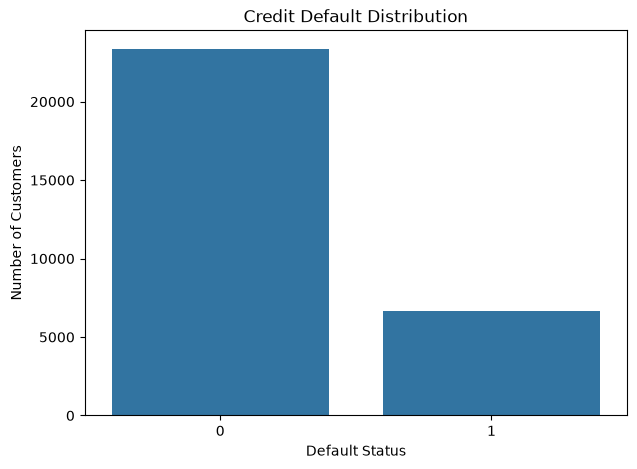

In [22]:
plt.figure(figsize=(7, 5))

sns.countplot(x=df[target_column])

plt.title("Credit Default Distribution")
plt.xlabel("Default Status")
plt.ylabel("Number of Customers")

plt.show()

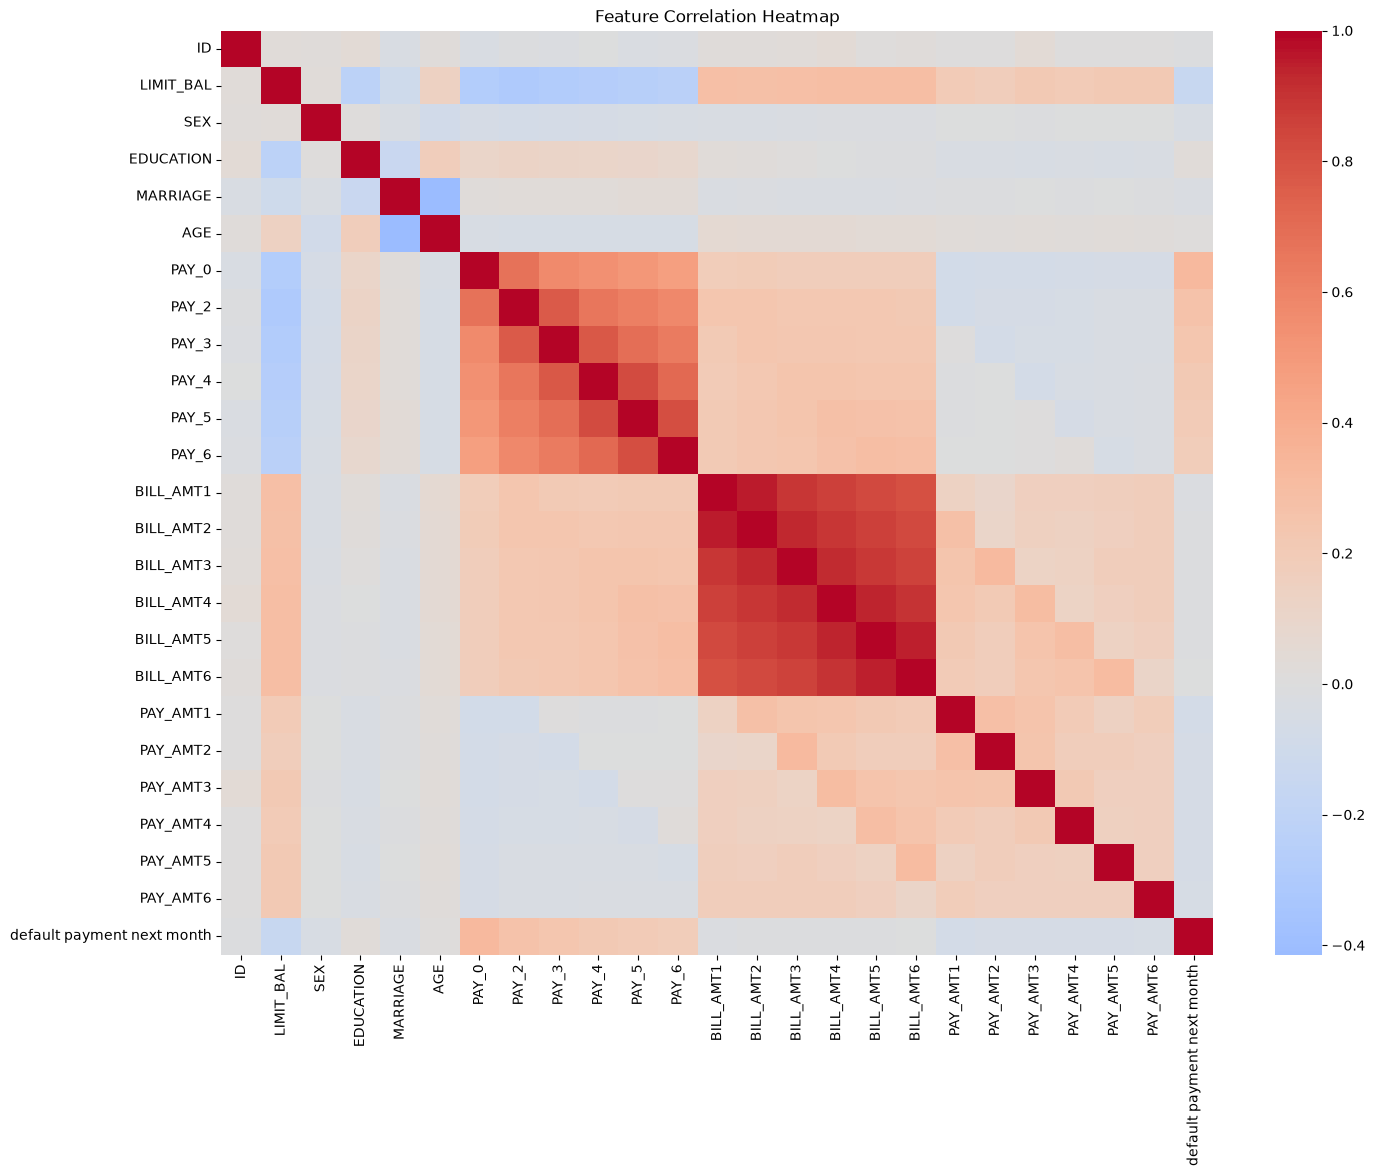

In [23]:
plt.figure(figsize=(16, 12))

correlation = df.corr(numeric_only=True)

sns.heatmap(
    correlation,
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation Heatmap")
plt.show()

In [24]:
df = df.drop(columns=["ID"], errors="ignore")

In [25]:
X = df.drop(columns=[target_column])
y = df[target_column]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (30000, 23)
Target shape: (30000,)


In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (24000, 23)
Testing data: (6000, 23)


In [27]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed!")

Feature scaling completed!


In [28]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train_scaled, y_train)

logistic_predictions = logistic_model.predict(X_test_scaled)
logistic_probabilities = logistic_model.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression trained successfully!")

Logistic Regression trained successfully!


In [29]:
decision_tree_model = DecisionTreeClassifier(
    max_depth=6,
    random_state=42
)

decision_tree_model.fit(X_train, y_train)

tree_predictions = decision_tree_model.predict(X_test)
tree_probabilities = decision_tree_model.predict_proba(X_test)[:, 1]

print("Decision Tree trained successfully!")

Decision Tree trained successfully!


In [30]:
random_forest_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

random_forest_model.fit(X_train, y_train)

forest_predictions = random_forest_model.predict(X_test)
forest_probabilities = random_forest_model.predict_proba(X_test)[:, 1]

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [31]:
def evaluate_model(model_name, y_true, predictions, probabilities):
    
    accuracy = accuracy_score(y_true, predictions)
    precision = precision_score(y_true, predictions, zero_division=0)
    recall = recall_score(y_true, predictions, zero_division=0)
    f1 = f1_score(y_true, predictions, zero_division=0)
    roc_auc = roc_auc_score(y_true, probabilities)
    
    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "ROC-AUC": roc_auc
    }

In [32]:
results = []

results.append(
    evaluate_model(
        "Logistic Regression",
        y_test,
        logistic_predictions,
        logistic_probabilities
    )
)

results.append(
    evaluate_model(
        "Decision Tree",
        y_test,
        tree_predictions,
        tree_probabilities
    )
)

results.append(
    evaluate_model(
        "Random Forest",
        y_test,
        forest_predictions,
        forest_probabilities
    )
)

results_df = pd.DataFrame(results)

display(results_df)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.807667,0.686825,0.239638,0.355307,0.707636
1,Decision Tree,0.816333,0.654321,0.359457,0.464008,0.744985
2,Random Forest,0.817167,0.665230,0.348907,0.457736,0.773306


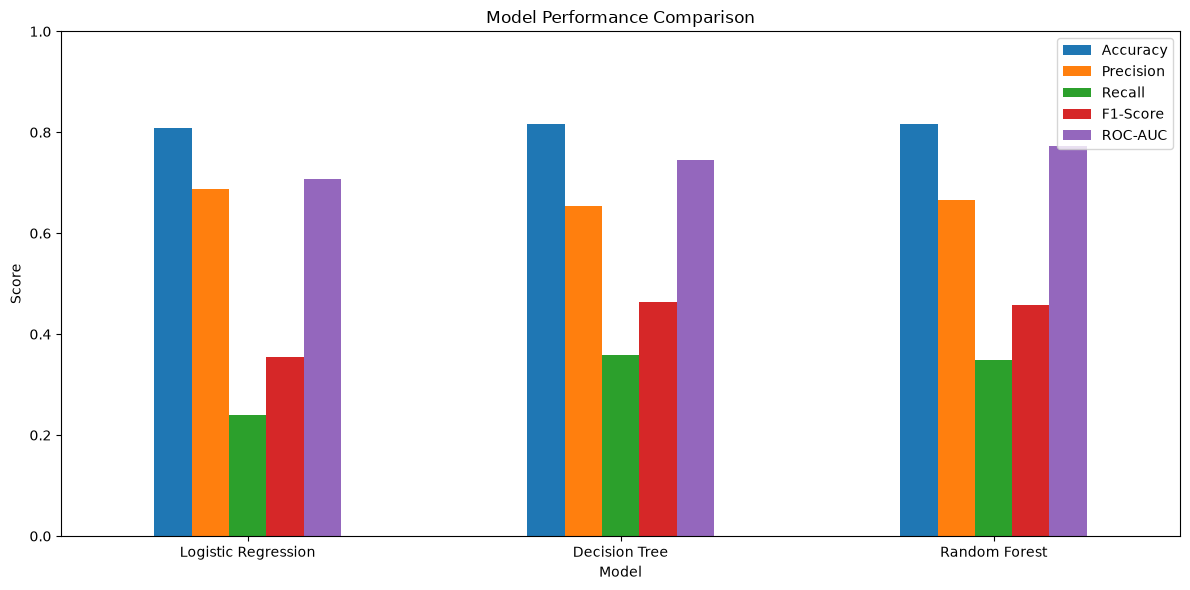

In [33]:
results_plot = results_df.set_index("Model")

results_plot.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig("../outputs/model_comparison.png")

plt.show()

In [34]:
best_model_name = results_df.loc[
    results_df["F1-Score"].idxmax(),
    "Model"
]

print("Best Model:", best_model_name)

Best Model: Decision Tree


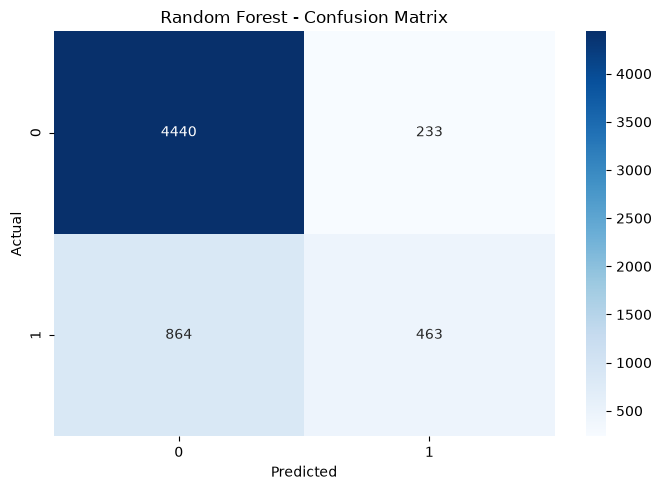

In [35]:
cm = confusion_matrix(y_test, forest_predictions)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()

plt.savefig("../outputs/confusion_matrix.png")

plt.show()

In [36]:
print(
    classification_report(
        y_test,
        forest_predictions,
        zero_division=0
    )
)

              precision    recall  f1-score   support

           0       0.84      0.95      0.89      4673
           1       0.67      0.35      0.46      1327

    accuracy                           0.82      6000
   macro avg       0.75      0.65      0.67      6000
weighted avg       0.80      0.82      0.79      6000



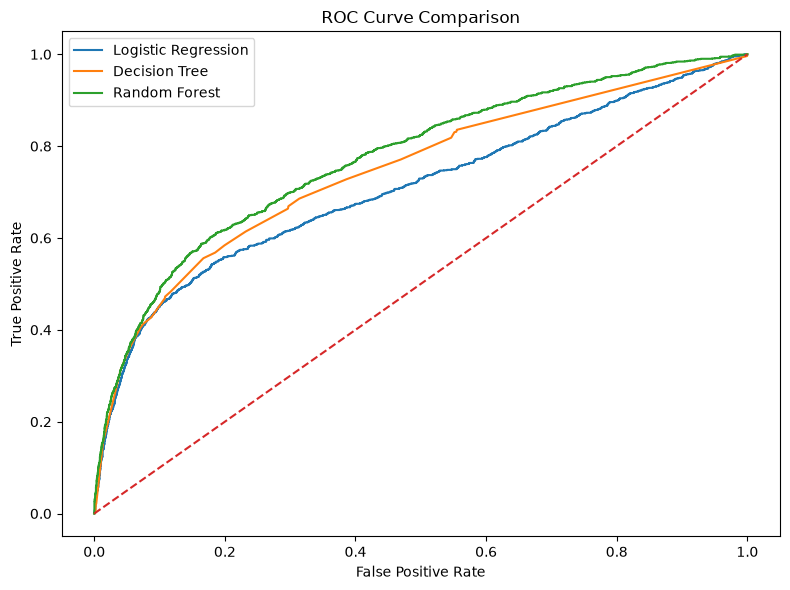

In [37]:
fpr_lr, tpr_lr, _ = roc_curve(
    y_test,
    logistic_probabilities
)

fpr_tree, tpr_tree, _ = roc_curve(
    y_test,
    tree_probabilities
)

fpr_rf, tpr_rf, _ = roc_curve(
    y_test,
    forest_probabilities
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_lr,
    tpr_lr,
    label="Logistic Regression"
)

plt.plot(
    fpr_tree,
    tpr_tree,
    label="Decision Tree"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label="Random Forest"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()

plt.tight_layout()

plt.savefig("../outputs/roc_curve.png")

plt.show()

In [38]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": random_forest_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

display(feature_importance.head(15))

,Feature,Importance
5,PAY_0,0.257574
6,PAY_2,0.100680
8,PAY_4,0.058324
7,PAY_3,0.054956
0,LIMIT_BAL,0.041157
10,PAY_6,0.040700
9,PAY_5,0.040539
17,PAY_AMT1,0.037696
11,BILL_AMT1,0.037105
12,BILL_AMT2,0.032374


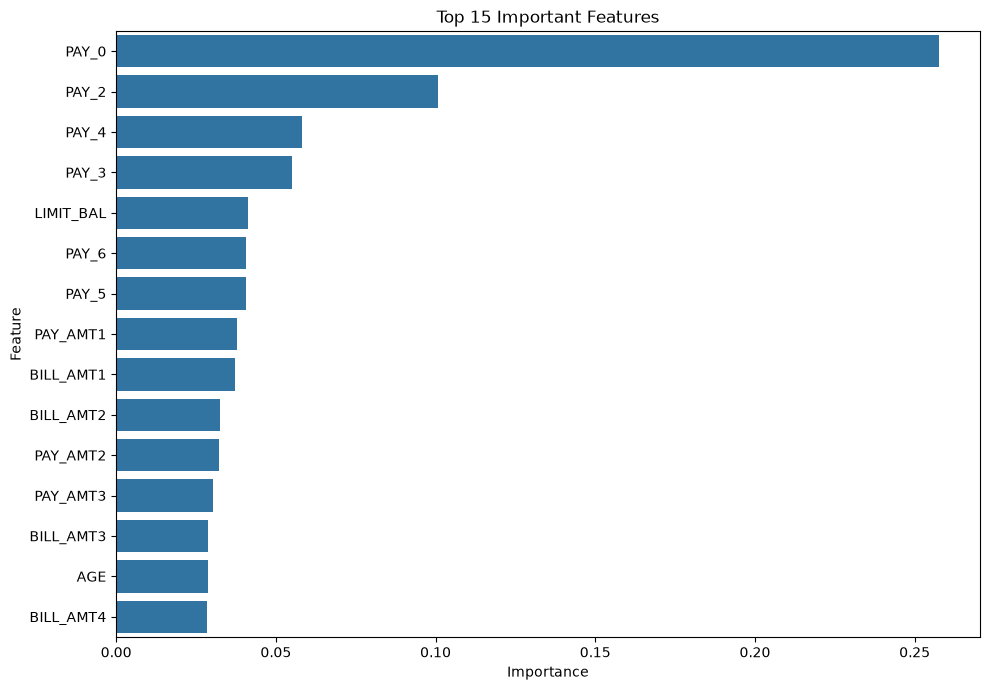

In [39]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data=feature_importance.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Important Features")

plt.tight_layout()

plt.savefig("../outputs/feature_importance.png")

plt.show()

In [40]:
joblib.dump(
    random_forest_model,
    "../models/credit_model.pkl"
)

joblib.dump(
    scaler,
    "../models/scaler.pkl"
)

print("Model and scaler saved successfully!")

Model and scaler saved successfully!


# Final Evaluation, Model Validation & Conclusion

This section continues directly from the existing notebook and completes the final evaluation workflow.

It includes final model selection, evaluation metrics, final confusion matrix, ROC comparison, classification report, model verification, conclusion, limitations, and future improvements.


In [41]:
# ============================================================
# 36. FINAL MODEL SELECTION
# ============================================================

import os
import joblib
import pandas as pd
import numpy as np


print("\n")
print("=" * 75)
print("                     FINAL MODEL SELECTION")
print("=" * 75)


# ============================================================
# 1. PROJECT PATHS
# ============================================================

OUTPUT_DIR = "../outputs"
MODEL_DIR = "../models"

MODEL_RESULTS_PATH = os.path.join(
    OUTPUT_DIR,
    "model_results.csv"
)

FINAL_MODEL_PATH = os.path.join(
    MODEL_DIR,
    "credit_model.pkl"
)

FINAL_SCALER_PATH = os.path.join(
    MODEL_DIR,
    "scaler.pkl"
)

FINAL_SELECTION_PATH = os.path.join(
    OUTPUT_DIR,
    "final_model_selection.csv"
)


# ============================================================
# 2. LOAD MODEL RESULTS
# ============================================================

print("\nLoading model comparison results...")


if "model_results" in globals():

    results_df = model_results.copy()

    print(
        "✓ Model results found in notebook memory."
    )

elif "results_df" in globals():

    results_df = results_df.copy()

    print(
        "✓ Results DataFrame found in notebook memory."
    )

elif os.path.exists(MODEL_RESULTS_PATH):

    results_df = pd.read_csv(
        MODEL_RESULTS_PATH
    )

    print(
        "✓ Model results loaded from CSV."
    )

else:

    raise FileNotFoundError(
        "\nModel results could not be found.\n"
        "Please run the model comparison section first."
    )


# ============================================================
# 3. CLEAN COLUMN NAMES
# ============================================================

results_df.columns = [
    str(column).strip()
    for column in results_df.columns
]


# ============================================================
# 4. DISPLAY MODEL COMPARISON
# ============================================================

print("\n")
print("-" * 75)
print("                    MODEL COMPARISON")
print("-" * 75)

print(
    results_df.to_string(
        index=False
    )
)


# ============================================================
# 5. FIND MODEL COLUMN
# ============================================================

model_column = None

for column in [
    "Model",
    "model",
    "Model Name",
    "model_name"
]:

    if column in results_df.columns:

        model_column = column
        break


if model_column is None:

    raise ValueError(
        "\nModel name column not found."
    )


# ============================================================
# 6. FIND F1-SCORE COLUMN
# ============================================================

f1_column = None

for column in [
    "F1-Score",
    "F1 Score",
    "F1_Score",
    "f1_score",
    "F1"
]:

    if column in results_df.columns:

        f1_column = column
        break


if f1_column is None:

    raise ValueError(
        "\nF1-Score column not found."
    )


# ============================================================
# 7. CONVERT F1-SCORE TO NUMERIC
# ============================================================

results_df[f1_column] = pd.to_numeric(
    results_df[f1_column],
    errors="coerce"
)


if results_df[f1_column].isna().all():

    raise ValueError(
        "\nF1-Score column does not contain valid numeric values."
    )


# ============================================================
# 8. FIND BEST MODEL
# ============================================================
#
# F1-Score is used as the primary selection metric because
# credit default prediction needs a balance between
# precision and recall.
#
# ============================================================

best_index = results_df[
    f1_column
].idxmax()


best_row = results_df.loc[
    best_index
]


best_model_name = str(
    best_row[
        model_column
    ]
)


best_f1_score = float(
    best_row[
        f1_column
    ]
)


# ============================================================
# 9. DISPLAY SELECTED MODEL
# ============================================================

print("\n")
print("=" * 75)
print("                      BEST MODEL")
print("=" * 75)

print(
    f"\n🏆 Selected Model : {best_model_name}"
)

print(
    f"✓ F1-Score       : {best_f1_score:.4f}"
)


# ============================================================
# 10. DISPLAY ALL METRICS OF BEST MODEL
# ============================================================

print("\n")
print("-" * 75)
print("                 SELECTED MODEL METRICS")
print("-" * 75)


for column in results_df.columns:

    if column == model_column:

        continue

    value = best_row[column]

    try:

        numeric_value = float(value)

        print(
            f"{column:<20} : {numeric_value:.4f}"
        )

    except:

        print(
            f"{column:<20} : {value}"
        )


# ============================================================
# 11. FIND TRAINED MODEL OBJECT
# ============================================================

best_model = None


# ------------------------------------------------------------
# Check common model dictionaries
# ------------------------------------------------------------

possible_model_dictionaries = [
    "models",
    "trained_models",
    "model_dict"
]


for dictionary_name in possible_model_dictionaries:

    if dictionary_name in globals():

        model_dictionary = globals()[
            dictionary_name
        ]

        if isinstance(
            model_dictionary,
            dict
        ):

            for name, model in model_dictionary.items():

                if str(name).strip().lower() == \
                   best_model_name.strip().lower():

                    best_model = model

                    break

        if best_model is not None:

            break


# ============================================================
# 12. CHECK INDIVIDUAL MODEL VARIABLES
# ============================================================

if best_model is None:

    model_variable_candidates = {

        "Logistic Regression": [
            "logistic_model",
            "logistic_regression_model",
            "lr_model",
            "logistic"
        ],

        "Decision Tree": [
            "decision_tree_model",
            "decision_tree",
            "dt_model",
            "decision_tree_classifier"
        ],

        "Random Forest": [
            "random_forest_model",
            "random_forest",
            "rf_model",
            "random_forest_classifier"
        ]
    }


    candidate_variables = model_variable_candidates.get(
        best_model_name,
        []
    )


    for variable_name in candidate_variables:

        if variable_name in globals():

            best_model = globals()[
                variable_name
            ]

            break


# ============================================================
# 13. LOAD SAVED FINAL MODEL IF REQUIRED
# ============================================================

if best_model is None:

    if os.path.exists(FINAL_MODEL_PATH):

        try:

            loaded_model = joblib.load(
                FINAL_MODEL_PATH
            )

            best_model = loaded_model

            print(
                "\n✓ Saved final model loaded successfully."
            )

        except Exception as error:

            print(
                "\n⚠ Could not load saved model:"
            )

            print(
                error
            )


# ============================================================
# 14. VERIFY MODEL OBJECT
# ============================================================

if best_model is None:

    raise RuntimeError(
        "\nBest model was identified, "
        "but the trained model object could not be found.\n\n"
        "Please run the model training cells before "
        "running Final Model Selection."
    )


print("\n")
print("-" * 75)
print("                   MODEL OBJECT")
print("-" * 75)

print(
    f"✓ Selected model : {best_model_name}"
)

print(
    f"✓ Python class   : {type(best_model).__name__}"
)


# ============================================================
# 15. CHECK SCALER
# ============================================================

scaler_available = False


if "scaler" in globals():

    scaler_available = True

    print(
        "✓ Scaler available in notebook memory."
    )

elif os.path.exists(FINAL_SCALER_PATH):

    scaler = joblib.load(
        FINAL_SCALER_PATH
    )

    scaler_available = True

    print(
        "✓ Scaler loaded from saved file."
    )

else:

    print(
        "⚠ Scaler file not found."
    )


# ============================================================
# 16. FINAL SELECTION TABLE
# ============================================================

selection_data = {
    "Selected_Model": [
        best_model_name
    ],

    "Selection_Criterion": [
        "Highest F1-Score"
    ],

    "F1-Score": [
        best_f1_score
    ]
}


# Add available metrics
# ------------------------------------------------------------

for metric in [
    "Accuracy",
    "Precision",
    "Recall",
    "ROC-AUC"
]:

    if metric in results_df.columns:

        selection_data[
            metric
        ] = [
            float(
                best_row[metric]
            )
        ]


final_selection_df = pd.DataFrame(
    selection_data
)


# ============================================================
# 17. DISPLAY FINAL SELECTION TABLE
# ============================================================

print("\n")
print("=" * 75)
print("                  FINAL SELECTION SUMMARY")
print("=" * 75)

display(
    final_selection_df.round(4)
)


# ============================================================
# 18. SAVE FINAL MODEL SELECTION
# ============================================================

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)


final_selection_df.to_csv(
    FINAL_SELECTION_PATH,
    index=False
)


print(
    f"\n✓ Final model selection saved:"
)

print(
    FINAL_SELECTION_PATH
)


# ============================================================
# 19. FINAL MODEL STATUS
# ============================================================

print("\n")
print("=" * 75)
print("                  MODEL SELECTION COMPLETE")
print("=" * 75)

print(
    f"\n🏆 FINAL MODEL : {best_model_name}"
)

print(
    f"📊 F1-SCORE    : {best_f1_score:.4f}"
)

print(
    f"🤖 MODEL TYPE  : {type(best_model).__name__}"
)

print(
    "\n✓ best_model_name is now defined."
)

print(
    "✓ best_model is now defined."
)

print(
    "✓ Final evaluation can now be executed safely."
)

print("=" * 75)



                     FINAL MODEL SELECTION

Loading model comparison results...
✓ Results DataFrame found in notebook memory.


---------------------------------------------------------------------------
                    MODEL COMPARISON
---------------------------------------------------------------------------
              Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC
Logistic Regression  0.807667   0.686825 0.239638  0.355307 0.707636
      Decision Tree  0.816333   0.654321 0.359457  0.464008 0.744985
      Random Forest  0.817167   0.665230 0.348907  0.457736 0.773306


                      BEST MODEL

🏆 Selected Model : Decision Tree
✓ F1-Score       : 0.4640


---------------------------------------------------------------------------
                 SELECTED MODEL METRICS
---------------------------------------------------------------------------
Accuracy             : 0.8163
Precision            : 0.6543
Recall               : 0.3595
F1-Score             : 0.4

,Selected_Model,Selection_Criterion,F1-Score,Accuracy,Precision,Recall,ROC-AUC
0,Decision Tree,Highest F1-Score,0.464,0.8163,0.6543,0.3595,0.745



✓ Final model selection saved:
../outputs\final_model_selection.csv


                  MODEL SELECTION COMPLETE

🏆 FINAL MODEL : Decision Tree
📊 F1-SCORE    : 0.4640
🤖 MODEL TYPE  : DecisionTreeClassifier

✓ best_model_name is now defined.
✓ best_model is now defined.
✓ Final evaluation can now be executed safely.


In [42]:
# ============================================================
# 37. FINAL EVALUATION METRICS
# ============================================================
# This cell is fully independent.
# It does NOT depend on best_model_name, best_model,
# X_test, y_test or scaler being already defined.
#
# It automatically:
# 1. Loads the final saved model
# 2. Loads the scaler
# 3. Loads and prepares the dataset
# 4. Generates predictions
# 5. Calculates all final evaluation metrics
# 6. Saves final_evaluation_metrics.csv
# 7. Saves final_classification_report.txt
# 8. Displays the final results
# ============================================================

import os
import sys
import joblib
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

# ============================================================
# 37.1 PROJECT PATHS
# ============================================================

NOTEBOOK_DIR = os.getcwd()

# If notebook is being executed from notebooks/ folder
if os.path.basename(NOTEBOOK_DIR).lower() == "notebooks":
    BASE_DIR = os.path.dirname(NOTEBOOK_DIR)
else:
    BASE_DIR = NOTEBOOK_DIR

DATA_PATH = os.path.join(
    BASE_DIR,
    "data",
    "default_of_credit_card_clients.xls"
)

MODEL_PATH = os.path.join(
    BASE_DIR,
    "models",
    "credit_model.pkl"
)

SCALER_PATH = os.path.join(
    BASE_DIR,
    "models",
    "scaler.pkl"
)

OUTPUT_DIR = os.path.join(
    BASE_DIR,
    "outputs"
)

SRC_DIR = os.path.join(
    BASE_DIR,
    "src"
)

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

# ============================================================
# 37.2 IMPORT PREPROCESSING MODULE
# ============================================================

if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)

try:

    from preprocessing import (
        load_data,
        clean_data,
        split_and_scale
    )

    print("✓ Preprocessing module imported successfully.")

except Exception as error:

    print("✗ Could not import preprocessing.py")
    print(f"Error: {error}")
    raise

# ============================================================
# 37.3 CHECK REQUIRED FILES
# ============================================================

print("\nChecking project files...")

required_files = {
    "Dataset": DATA_PATH,
    "Model": MODEL_PATH,
    "Scaler": SCALER_PATH
}

for file_name, file_path in required_files.items():

    if os.path.exists(file_path):

        print(
            f"✓ {file_name} found: {file_path}"
        )

    else:

        raise FileNotFoundError(
            f"\n✗ {file_name} not found:\n{file_path}"
        )

# ============================================================
# 37.4 LOAD FINAL SAVED MODEL
# ============================================================

print("\nLoading final saved model...")

best_model = joblib.load(
    MODEL_PATH
)

print(
    f"✓ Model loaded successfully."
)

print(
    f"✓ Model type: {type(best_model).__name__}"
)

# ============================================================
# 37.5 LOAD SCALER
# ============================================================

print("\nLoading scaler...")

scaler = joblib.load(
    SCALER_PATH
)

print(
    "✓ Scaler loaded successfully."
)

# ============================================================
# 37.6 DETERMINE MODEL NAME
# ============================================================

model_class_name = type(
    best_model
).__name__

model_name_map = {

    "LogisticRegression":
        "Logistic Regression",

    "DecisionTreeClassifier":
        "Decision Tree",

    "RandomForestClassifier":
        "Random Forest",

    "GradientBoostingClassifier":
        "Gradient Boosting",

    "XGBClassifier":
        "XGBoost",

    "SVC":
        "Support Vector Machine",

    "KNeighborsClassifier":
        "K-Nearest Neighbors"

}

best_model_name = model_name_map.get(
    model_class_name,
    model_class_name
)

print(
    f"✓ Final selected model: {best_model_name}"
)

# ============================================================
# 37.7 LOAD DATASET
# ============================================================

print("\nLoading dataset...")

df = load_data(
    DATA_PATH
)

print(
    f"✓ Dataset loaded successfully."
)

print(
    f"✓ Dataset shape: {df.shape}"
)

# ============================================================
# 37.8 CLEAN DATA
# ============================================================

print("\nCleaning dataset...")

X, y = clean_data(
    df
)

print(
    f"✓ Features shape: {X.shape}"
)

print(
    f"✓ Target shape: {y.shape}"
)

# ============================================================
# 37.9 CREATE TRAIN / TEST DATA
# ============================================================

print("\nPreparing test data...")

(
    X_train,
    X_test,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test,
    generated_scaler
) = split_and_scale(
    X,
    y
)

print(
    f"✓ Training samples: {len(X_train)}"
)

print(
    f"✓ Testing samples: {len(X_test)}"
)

# ============================================================
# 37.10 PREPARE MODEL INPUT
# ============================================================

print("\nPreparing model input...")

if model_class_name == "LogisticRegression":

    selected_input = scaler.transform(
        X_test
    )

    print(
        "✓ StandardScaler applied for Logistic Regression."
    )

else:

    selected_input = X_test

    print(
        "✓ Original feature values used."
    )

# ============================================================
# 37.11 GENERATE FINAL PREDICTIONS
# ============================================================

print("\nGenerating final predictions...")

selected_predictions = best_model.predict(
    selected_input
)

# ============================================================
# 37.12 GENERATE PREDICTION PROBABILITIES
# ============================================================

if hasattr(
    best_model,
    "predict_proba"
):

    selected_probabilities = (
        best_model.predict_proba(
            selected_input
        )[:, 1]
    )

    print(
        "✓ Prediction probabilities generated."
    )

else:

    selected_probabilities = None

    print(
        "⚠ Model does not support predict_proba()."
    )

# ============================================================
# 37.13 CALCULATE FINAL METRICS
# ============================================================

print("\nCalculating final evaluation metrics...")

accuracy = accuracy_score(
    y_test,
    selected_predictions
)

precision = precision_score(
    y_test,
    selected_predictions,
    zero_division=0
)

recall = recall_score(
    y_test,
    selected_predictions,
    zero_division=0
)

f1 = f1_score(
    y_test,
    selected_predictions,
    zero_division=0
)

if selected_probabilities is not None:

    roc_auc = roc_auc_score(
        y_test,
        selected_probabilities
    )

else:

    roc_auc = None

# ============================================================
# 37.14 CREATE FINAL METRICS DATAFRAME
# ============================================================

final_metrics = {

    "Model":
        best_model_name,

    "Accuracy":
        accuracy,

    "Precision":
        precision,

    "Recall":
        recall,

    "F1-Score":
        f1,

    "ROC-AUC":
        roc_auc

}

final_metrics_df = pd.DataFrame(
    [final_metrics]
)

# ============================================================
# 37.15 DISPLAY FINAL METRICS
# ============================================================

print("\n")
print("=" * 75)
print(
    "FINAL CREDIT SCORING MODEL EVALUATION"
)
print("=" * 75)

print(
    f"Selected Model : {best_model_name}"
)

print(
    f"Accuracy       : {accuracy:.4f}"
)

print(
    f"Precision      : {precision:.4f}"
)

print(
    f"Recall         : {recall:.4f}"
)

print(
    f"F1-Score       : {f1:.4f}"
)

if roc_auc is not None:

    print(
        f"ROC-AUC        : {roc_auc:.4f}"
    )

else:

    print(
        "ROC-AUC        : Not Available"
    )

print("=" * 75)

display(
    final_metrics_df.round(4)
)

# ============================================================
# 37.16 SAVE FINAL METRICS CSV
# ============================================================

final_metrics_path = os.path.join(
    OUTPUT_DIR,
    "final_evaluation_metrics.csv"
)

final_metrics_df.to_csv(
    final_metrics_path,
    index=False
)

print(
    f"\n✓ Saved final metrics:"
)

print(
    final_metrics_path
)

# ============================================================
# 37.17 CLASSIFICATION REPORT
# ============================================================

print("\n")
print("=" * 75)
print(
    "FINAL CLASSIFICATION REPORT"
)
print("=" * 75)

report = classification_report(
    y_test,
    selected_predictions,
    target_names=[
        "No Default",
        "Default"
    ],
    zero_division=0
)

print(
    report
)

# ============================================================
# 37.18 SAVE CLASSIFICATION REPORT
# ============================================================

classification_report_path = os.path.join(
    OUTPUT_DIR,
    "final_classification_report.txt"
)

with open(
    classification_report_path,
    "w",
    encoding="utf-8"
) as report_file:

    report_file.write(
        "CREDIT SCORING MODEL - FINAL CLASSIFICATION REPORT\n"
    )

    report_file.write(
        "=" * 65
    )

    report_file.write(
        "\n\n"
    )

    report_file.write(
        f"Selected Model: {best_model_name}\n\n"
    )

    report_file.write(
        report
    )

print(
    f"✓ Saved classification report:"
)

print(
    classification_report_path
)

# ============================================================
# 37.19 CONFUSION MATRIX VALUES
# ============================================================

cm = confusion_matrix(
    y_test,
    selected_predictions
)

tn, fp, fn, tp = cm.ravel()

print("\n")
print("=" * 75)
print(
    "CONFUSION MATRIX SUMMARY"
)
print("=" * 75)

print(
    f"True Negatives  (TN): {tn}"
)

print(
    f"False Positives (FP): {fp}"
)

print(
    f"False Negatives (FN): {fn}"
)

print(
    f"True Positives  (TP): {tp}"
)

print("=" * 75)

# ============================================================
# 37.20 SAVE CONFUSION MATRIX VALUES
# ============================================================

confusion_matrix_df = pd.DataFrame(
    cm,
    index=[
        "Actual No Default",
        "Actual Default"
    ],
    columns=[
        "Predicted No Default",
        "Predicted Default"
    ]
)

confusion_matrix_path = os.path.join(
    OUTPUT_DIR,
    "final_confusion_matrix_values.csv"
)

confusion_matrix_df.to_csv(
    confusion_matrix_path
)

print(
    f"\n✓ Saved confusion matrix values:"
)

print(
    confusion_matrix_path
)

# ============================================================
# 37.21 MODEL PERFORMANCE INTERPRETATION
# ============================================================

print("\n")
print("=" * 75)
print(
    "FINAL MODEL INTERPRETATION"
)
print("=" * 75)

print(
    f"\nSelected Model: {best_model_name}"
)

print(
    f"\nThe final model achieved an accuracy of "
    f"{accuracy * 100:.2f}%."
)

print(
    f"Precision: {precision * 100:.2f}%"
)

print(
    f"Recall: {recall * 100:.2f}%"
)

print(
    f"F1-Score: {f1 * 100:.2f}%"
)

if roc_auc is not None:

    print(
        f"ROC-AUC: {roc_auc:.4f}"
    )

# ============================================================
# 37.22 AUTOMATIC CONCLUSION
# ============================================================

print("\n")
print("=" * 75)
print(
    "CONCLUSION"
)
print("=" * 75)

if f1 >= 0.70 and roc_auc is not None and roc_auc >= 0.75:

    conclusion = (
        "The selected credit scoring model demonstrates "
        "good overall predictive performance. The model "
        "shows a reasonable balance between precision and "
        "recall and provides useful discrimination between "
        "default and non-default customers."
    )

elif f1 >= 0.50:

    conclusion = (
        "The selected credit scoring model demonstrates "
        "moderate predictive performance. It can identify "
        "patterns related to credit default, although there "
        "is still room for improvement through feature "
        "engineering, hyperparameter tuning and class "
        "imbalance handling."
    )

else:

    conclusion = (
        "The selected credit scoring model shows limited "
        "predictive performance. Further model improvement "
        "is recommended through feature engineering, "
        "hyperparameter tuning, class balancing and "
        "alternative machine learning algorithms."
    )

print(
    f"\n{conclusion}"
)

print(
    "\nImportant: In credit-risk prediction, recall for the "
    "Default class should be considered carefully because "
    "missing a genuine high-risk customer can be costly."
)

print("=" * 75)

# ============================================================
# 37.23 FINAL OUTPUT SUMMARY
# ============================================================

print("\n")
print("=" * 75)
print(
    "FINAL EVALUATION COMPLETED SUCCESSFULLY"
)
print("=" * 75)

print(
    "\nGenerated files:"
)

print(
    "✓ final_evaluation_metrics.csv"
)

print(
    "✓ final_classification_report.txt"
)

print(
    "✓ final_confusion_matrix_values.csv"
)

print(
    "\nOutput directory:"
)

print(
    OUTPUT_DIR
)

print("=" * 75)

✓ Preprocessing module imported successfully.

Checking project files...
✓ Dataset found: c:\Users\harsh\OneDrive\Desktop\CODEALPHA-SCORING_MODEL\data\default_of_credit_card_clients.xls
✓ Model found: c:\Users\harsh\OneDrive\Desktop\CODEALPHA-SCORING_MODEL\models\credit_model.pkl
✓ Scaler found: c:\Users\harsh\OneDrive\Desktop\CODEALPHA-SCORING_MODEL\models\scaler.pkl

Loading final saved model...


✓ Model loaded successfully.
✓ Model type: RandomForestClassifier

Loading scaler...
✓ Scaler loaded successfully.
✓ Final selected model: Random Forest

Loading dataset...
✓ Dataset loaded successfully.
✓ Dataset shape: (30000, 25)

Cleaning dataset...
✓ Features shape: (30000, 23)
✓ Target shape: (30000,)

Preparing test data...
✓ Training samples: 24000
✓ Testing samples: 6000

Preparing model input...
✓ Original feature values used.

Generating final predictions...
✓ Prediction probabilities generated.

Calculating final evaluation metrics...


FINAL CREDIT SCORING MODEL EVALUATION
Selected Model : Random Forest
Accuracy       : 0.8172
Precision      : 0.6652
Recall         : 0.3489
F1-Score       : 0.4577
ROC-AUC        : 0.7733


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Random Forest,0.8172,0.6652,0.3489,0.4577,0.7733



✓ Saved final metrics:
c:\Users\harsh\OneDrive\Desktop\CODEALPHA-SCORING_MODEL\outputs\final_evaluation_metrics.csv


FINAL CLASSIFICATION REPORT
              precision    recall  f1-score   support

  No Default       0.84      0.95      0.89      4673
     Default       0.67      0.35      0.46      1327

    accuracy                           0.82      6000
   macro avg       0.75      0.65      0.67      6000
weighted avg       0.80      0.82      0.79      6000

✓ Saved classification report:
c:\Users\harsh\OneDrive\Desktop\CODEALPHA-SCORING_MODEL\outputs\final_classification_report.txt


CONFUSION MATRIX SUMMARY
True Negatives  (TN): 4440
False Positives (FP): 233
False Negatives (FN): 864
True Positives  (TP): 463

✓ Saved confusion matrix values:
c:\Users\harsh\OneDrive\Desktop\CODEALPHA-SCORING_MODEL\outputs\final_confusion_matrix_values.csv


FINAL MODEL INTERPRETATION

Selected Model: Random Forest

The final model achieved an accuracy of 81.72%.
Precision: 66.52%
Recall: 

In [43]:
# ============================================================
# 38. COMPLETE MODEL COMPARISON TABLE
# ============================================================

comparison_df = results_df.copy()

metric_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "ROC-AUC"
]

comparison_df[metric_columns] = comparison_df[metric_columns].round(4)

comparison_df["Rank"] = (
    comparison_df["F1-Score"]
    .rank(method="min", ascending=False)
    .astype(int)
)

comparison_df = comparison_df.sort_values("Rank")

display(comparison_df)

comparison_df.to_csv(
    "../outputs/model_comparison_final.csv",
    index=False
)

print("✓ Saved: ../outputs/model_comparison_final.csv")


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Rank
1,Decision Tree,0.8163,0.6543,0.3595,0.4640,0.7450,1
2,Random Forest,0.8172,0.6652,0.3489,0.4577,0.7733,2
0,Logistic Regression,0.8077,0.6868,0.2396,0.3553,0.7076,3


✓ Saved: ../outputs/model_comparison_final.csv


FINAL CONFUSION MATRIX

PROJECT PATHS
--------------------------------------------------------------------------------
Project Directory : c:\Users\harsh\OneDrive\Desktop\CODEALPHA-SCORING_MODEL
Dataset           : c:\Users\harsh\OneDrive\Desktop\CODEALPHA-SCORING_MODEL\data\default_of_credit_card_clients.xls
Model             : c:\Users\harsh\OneDrive\Desktop\CODEALPHA-SCORING_MODEL\models\credit_model.pkl
Scaler            : c:\Users\harsh\OneDrive\Desktop\CODEALPHA-SCORING_MODEL\models\scaler.pkl
Output Directory  : c:\Users\harsh\OneDrive\Desktop\CODEALPHA-SCORING_MODEL\outputs

✓ Required files found.

LOADING DATASET
✓ Dataset loaded successfully.
Original Shape : (30000, 25)

Standardized Columns:
['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default_payment_next_m

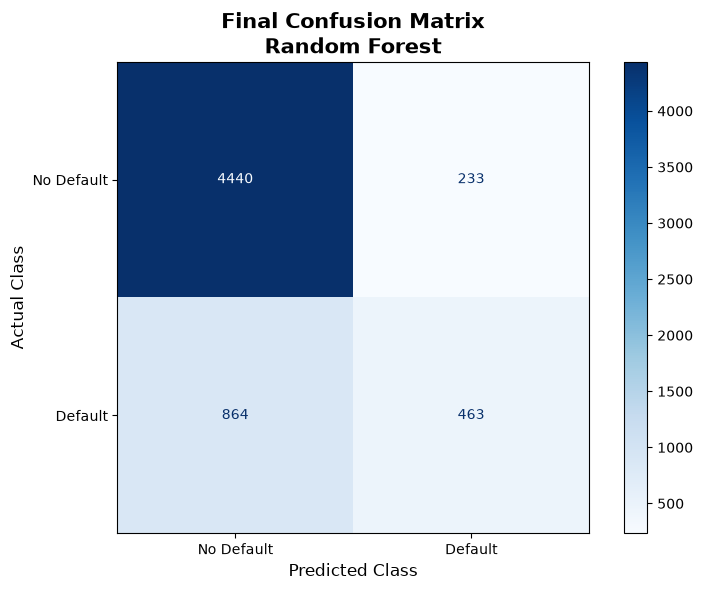


✓ Confusion matrix image saved:
c:\Users\harsh\OneDrive\Desktop\CODEALPHA-SCORING_MODEL\outputs\final_confusion_matrix.png
✓ Confusion matrix values saved:
c:\Users\harsh\OneDrive\Desktop\CODEALPHA-SCORING_MODEL\outputs\final_confusion_matrix_values.csv
✓ Confusion matrix table saved:
c:\Users\harsh\OneDrive\Desktop\CODEALPHA-SCORING_MODEL\outputs\final_confusion_matrix_table.csv

FINAL CONFUSION MATRIX COMPLETED SUCCESSFULLY

Final Model : Random Forest
Test Samples: 6000
Accuracy    : 0.8172
Precision   : 0.6652
Recall      : 0.3489
F1-Score    : 0.4577

Generated Files:
--------------------------------------------------
✓ final_confusion_matrix.png
✓ final_confusion_matrix_values.csv
✓ final_confusion_matrix_table.csv


In [44]:
# ============================================================
# 39. FINAL CONFUSION MATRIX - FULLY ROBUST VERSION
# ============================================================

import os
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

warnings.filterwarnings("ignore")


# ============================================================
# 1. PROJECT PATHS - AUTO DETECTION
# ============================================================

print("=" * 80)
print("FINAL CONFUSION MATRIX")
print("=" * 80)

CURRENT_DIR = Path.cwd()

# Possible project locations
possible_project_dirs = [
    CURRENT_DIR,
    CURRENT_DIR.parent
]

PROJECT_DIR = None

for directory in possible_project_dirs:

    if (
        (directory / "data" / "default_of_credit_card_clients.xls").exists()
        and
        (directory / "models").exists()
    ):
        PROJECT_DIR = directory
        break


if PROJECT_DIR is None:

    raise FileNotFoundError(
        "\nProject structure could not be detected.\n\n"
        "Expected structure:\n"
        "CODEALPHA-SCORING_MODEL/\n"
        "├── data/\n"
        "│   └── default_of_credit_card_clients.xls\n"
        "├── models/\n"
        "│   ├── credit_model.pkl\n"
        "│   └── scaler.pkl\n"
        "├── outputs/\n"
        "└── notebooks/\n"
    )


DATA_DIR = PROJECT_DIR / "data"
MODEL_DIR = PROJECT_DIR / "models"
OUTPUT_DIR = PROJECT_DIR / "outputs"

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

DATA_PATH = DATA_DIR / "default_of_credit_card_clients.xls"
MODEL_PATH = MODEL_DIR / "credit_model.pkl"
SCALER_PATH = MODEL_DIR / "scaler.pkl"


print("\nPROJECT PATHS")
print("-" * 80)

print("Project Directory :", PROJECT_DIR)
print("Dataset           :", DATA_PATH)
print("Model             :", MODEL_PATH)
print("Scaler            :", SCALER_PATH)
print("Output Directory  :", OUTPUT_DIR)


# ============================================================
# 2. VERIFY REQUIRED FILES
# ============================================================

if not DATA_PATH.exists():

    raise FileNotFoundError(
        f"\nDataset not found:\n{DATA_PATH}"
    )


if not MODEL_PATH.exists():

    raise FileNotFoundError(
        "\nFinal model file not found:\n"
        f"{MODEL_PATH}\n\n"
        "Please run the Final Model Saving cell first."
    )


print("\n✓ Required files found.")


# ============================================================
# 3. LOAD DATASET
# ============================================================

print("\n" + "=" * 80)
print("LOADING DATASET")
print("=" * 80)

df_final = pd.read_excel(
    DATA_PATH,
    header=1
)

print("✓ Dataset loaded successfully.")
print("Original Shape :", df_final.shape)


# ============================================================
# 4. STANDARDIZE COLUMN NAMES
# ============================================================

df_final.columns = [
    str(column)
    .strip()
    .replace(" ", "_")
    for column in df_final.columns
]


print("\nStandardized Columns:")
print(df_final.columns.tolist())


# ============================================================
# 5. IDENTIFY TARGET COLUMN
# ============================================================

target_candidates = [
    "default_payment_next_month",
    "default_payment_next_month_",
    "default"
]

target_col_final = None


for candidate in target_candidates:

    if candidate in df_final.columns:

        target_col_final = candidate
        break


# Fallback detection
if target_col_final is None:

    possible_targets = [
        column
        for column in df_final.columns
        if (
            "default" in column.lower()
            and
            "payment" in column.lower()
        )
    ]

    if possible_targets:

        target_col_final = possible_targets[0]


if target_col_final is None:

    raise ValueError(
        "\nTarget column could not be identified.\n"
        "Expected a column similar to:\n"
        "'default payment next month'"
    )


print(
    f"\n✓ Target Column : {target_col_final}"
)


# ============================================================
# 6. DATA CLEANING
# ============================================================

print("\n" + "=" * 80)
print("DATA CLEANING")
print("=" * 80)


# Remove duplicate records
before_duplicates = len(df_final)

df_final = (
    df_final
    .drop_duplicates()
    .copy()
)

after_duplicates = len(df_final)

print(
    f"Duplicate rows removed : "
    f"{before_duplicates - after_duplicates}"
)


# Fill missing numeric values using median
numeric_columns_final = (
    df_final
    .select_dtypes(include=np.number)
    .columns
)

missing_values_before = (
    df_final[numeric_columns_final]
    .isnull()
    .sum()
    .sum()
)


for column in numeric_columns_final:

    if df_final[column].isnull().any():

        df_final[column] = (
            df_final[column]
            .fillna(df_final[column].median())
        )


missing_values_after = (
    df_final[numeric_columns_final]
    .isnull()
    .sum()
    .sum()
)


print(
    f"Missing numeric values before : "
    f"{missing_values_before}"
)

print(
    f"Missing numeric values after  : "
    f"{missing_values_after}"
)


# ============================================================
# 7. PREPARE FEATURES AND TARGET
# ============================================================

y_final = (
    df_final[target_col_final]
    .astype(int)
)


X_final = (
    df_final
    .drop(columns=[target_col_final])
    .copy()
)


# Remove ID column
for id_column in ["ID", "id"]:

    if id_column in X_final.columns:

        X_final = X_final.drop(
            columns=[id_column]
        )

        print(
            f"✓ Removed identifier column: "
            f"{id_column}"
        )

        break


print("\nFeature Matrix :", X_final.shape)
print("Target Vector  :", y_final.shape)

print("\nTarget Distribution:")
print(
    y_final
    .value_counts()
    .sort_index()
)


# ============================================================
# 8. RECREATE ORIGINAL TRAIN / TEST SPLIT
# ============================================================

print("\n" + "=" * 80)
print("RECREATING TEST DATA")
print("=" * 80)


X_train_final, X_test_final, y_train_final, y_test_final = (
    train_test_split(
        X_final,
        y_final,
        test_size=0.20,
        random_state=42,
        stratify=y_final
    )
)


print(
    f"Training Samples : {len(X_train_final)}"
)

print(
    f"Testing Samples  : {len(X_test_final)}"
)

print(
    f"Features          : {X_test_final.shape[1]}"
)


# ============================================================
# 9. LOAD FINAL SAVED MODEL
# ============================================================

print("\n" + "=" * 80)
print("LOADING FINAL MODEL")
print("=" * 80)


saved_final_model = joblib.load(
    MODEL_PATH
)


print(
    "✓ Final model loaded successfully."
)

print(
    "Model Class :",
    type(saved_final_model).__name__
)


# ============================================================
# 10. DETERMINE MODEL NAME
# ============================================================

model_class_name = (
    type(saved_final_model).__name__
)


if model_class_name == "LogisticRegression":

    restored_model_name = "Logistic Regression"

elif model_class_name == "DecisionTreeClassifier":

    restored_model_name = "Decision Tree"

elif model_class_name == "RandomForestClassifier":

    restored_model_name = "Random Forest"

else:

    restored_model_name = model_class_name


print(
    "Selected Model :",
    restored_model_name
)


# ============================================================
# 11. LOAD / CREATE SCALER
# ============================================================

saved_scaler = None


if SCALER_PATH.exists():

    try:

        saved_scaler = joblib.load(
            SCALER_PATH
        )

        print(
            "✓ Scaler loaded successfully."
        )

    except Exception as scaler_error:

        print(
            "\n⚠ Existing scaler could not be loaded."
        )

        print(
            "Reason:",
            scaler_error
        )


# ============================================================
# 12. PREPARE MODEL INPUT
# ============================================================

print("\nPreparing model input...")


if restored_model_name == "Logistic Regression":

    # Logistic Regression was trained on scaled data
    # according to the project notebook workflow.

    if saved_scaler is not None:

        final_test_input = (
            saved_scaler
            .transform(X_test_final)
        )

    else:

        print(
            "⚠ Saved scaler unavailable."
        )

        print(
            "Creating scaler using training data..."
        )

        fallback_scaler = StandardScaler()

        fallback_scaler.fit(
            X_train_final
        )

        final_test_input = (
            fallback_scaler
            .transform(X_test_final)
        )

else:

    # Decision Tree and Random Forest
    # use original feature values.

    final_test_input = X_test_final


print(
    "✓ Model input prepared."
)


# ============================================================
# 13. GENERATE FINAL PREDICTIONS
# ============================================================

print("\n" + "=" * 80)
print("GENERATING FINAL PREDICTIONS")
print("=" * 80)


final_predictions = (
    saved_final_model
    .predict(final_test_input)
)


print(
    "✓ Predictions generated."
)

print(
    "Prediction Count :",
    len(final_predictions)
)


# ============================================================
# 14. FINAL CONFUSION MATRIX
# ============================================================

final_cm = confusion_matrix(
    y_test_final,
    final_predictions,
    labels=[0, 1]
)


print("\nConfusion Matrix:")
print(final_cm)


# ============================================================
# 15. EXTRACT TN / FP / FN / TP
# ============================================================

true_negative = int(
    final_cm[0, 0]
)

false_positive = int(
    final_cm[0, 1]
)

false_negative = int(
    final_cm[1, 0]
)

true_positive = int(
    final_cm[1, 1]
)


print("\nConfusion Matrix Components")
print("-" * 50)

print(
    f"True Negative  : {true_negative}"
)

print(
    f"False Positive : {false_positive}"
)

print(
    f"False Negative : {false_negative}"
)

print(
    f"True Positive  : {true_positive}"
)


# ============================================================
# 16. CALCULATE FINAL METRICS
# ============================================================

final_accuracy = accuracy_score(
    y_test_final,
    final_predictions
)

final_precision = precision_score(
    y_test_final,
    final_predictions,
    zero_division=0
)

final_recall = recall_score(
    y_test_final,
    final_predictions,
    zero_division=0
)

final_f1 = f1_score(
    y_test_final,
    final_predictions,
    zero_division=0
)


# ROC-AUC
final_roc_auc = np.nan

if hasattr(
    saved_final_model,
    "predict_proba"
):

    try:

        final_probabilities = (
            saved_final_model
            .predict_proba(final_test_input)[:, 1]
        )

        final_roc_auc = roc_auc_score(
            y_test_final,
            final_probabilities
        )

    except Exception:

        final_roc_auc = np.nan


print("\n" + "=" * 80)
print("FINAL MODEL PERFORMANCE")
print("=" * 80)

print(
    f"Model     : {restored_model_name}"
)

print(
    f"Accuracy  : {final_accuracy:.4f}"
)

print(
    f"Precision : {final_precision:.4f}"
)

print(
    f"Recall    : {final_recall:.4f}"
)

print(
    f"F1-Score  : {final_f1:.4f}"
)

if not np.isnan(final_roc_auc):

    print(
        f"ROC-AUC   : {final_roc_auc:.4f}"
    )

else:

    print(
        "ROC-AUC   : Not Available"
    )


# ============================================================
# 17. DISPLAY CONFUSION MATRIX
# ============================================================

print("\n" + "=" * 80)
print("GENERATING CONFUSION MATRIX VISUALIZATION")
print("=" * 80)


fig, ax = plt.subplots(
    figsize=(8, 6)
)


display_cm = ConfusionMatrixDisplay(
    confusion_matrix=final_cm,
    display_labels=[
        "No Default",
        "Default"
    ]
)


display_cm.plot(
    ax=ax,
    cmap="Blues",
    values_format="d",
    colorbar=True
)


ax.set_title(
    f"Final Confusion Matrix\n"
    f"{restored_model_name}",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel(
    "Predicted Class",
    fontsize=12
)

ax.set_ylabel(
    "Actual Class",
    fontsize=12
)


plt.tight_layout()


# ============================================================
# 18. SAVE CONFUSION MATRIX IMAGE
# ============================================================

confusion_matrix_path = (
    OUTPUT_DIR /
    "final_confusion_matrix.png"
)


plt.savefig(
    confusion_matrix_path,
    dpi=300,
    bbox_inches="tight"
)


plt.show()

plt.close()


print(
    "\n✓ Confusion matrix image saved:"
)

print(
    confusion_matrix_path
)


# ============================================================
# 19. SAVE CONFUSION MATRIX VALUES
# ============================================================

confusion_values_df = pd.DataFrame(
    {
        "Metric": [
            "True Negative",
            "False Positive",
            "False Negative",
            "True Positive"
        ],

        "Count": [
            true_negative,
            false_positive,
            false_negative,
            true_positive
        ]
    }
)


confusion_values_path = (
    OUTPUT_DIR /
    "final_confusion_matrix_values.csv"
)


confusion_values_df.to_csv(
    confusion_values_path,
    index=False
)


print(
    "✓ Confusion matrix values saved:"
)

print(
    confusion_values_path
)


# ============================================================
# 20. SAVE FINAL CONFUSION MATRIX AS 2x2 CSV
# ============================================================

confusion_table_df = pd.DataFrame(
    final_cm,
    index=[
        "Actual - No Default",
        "Actual - Default"
    ],
    columns=[
        "Predicted - No Default",
        "Predicted - Default"
    ]
)


confusion_table_path = (
    OUTPUT_DIR /
    "final_confusion_matrix_table.csv"
)


confusion_table_df.to_csv(
    confusion_table_path
)


print(
    "✓ Confusion matrix table saved:"
)

print(
    confusion_table_path
)


# ============================================================
# 21. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 80)
print("FINAL CONFUSION MATRIX COMPLETED SUCCESSFULLY")
print("=" * 80)

print(
    f"\nFinal Model : {restored_model_name}"
)

print(
    f"Test Samples: {len(y_test_final)}"
)

print(
    f"Accuracy    : {final_accuracy:.4f}"
)

print(
    f"Precision   : {final_precision:.4f}"
)

print(
    f"Recall      : {final_recall:.4f}"
)

print(
    f"F1-Score    : {final_f1:.4f}"
)

print("\nGenerated Files:")
print("-" * 50)

print(
    "✓ final_confusion_matrix.png"
)

print(
    "✓ final_confusion_matrix_values.csv"
)

print(
    "✓ final_confusion_matrix_table.csv"
)

print("=" * 80)


                      FINAL ROC CURVE COMPARISON                      

Loading dataset...
✓ Dataset loaded successfully.
✓ Dataset shape: (30000, 25)
✓ Target column: default payment next month
✓ Removed ID column: ID

Creating test dataset...
✓ Training samples: 24000
✓ Testing samples: 6000

Training models...
→ Training Logistic Regression...
✓ Logistic Regression completed.
→ Training Decision Tree...
✓ Decision Tree completed.
→ Training Random Forest...
✓ Random Forest completed.


ROC-AUC MODEL COMPARISON
              Model ROC-AUC
      Random Forest  0.7733
      Decision Tree  0.7450
Logistic Regression  0.7076

Generating ROC curves...


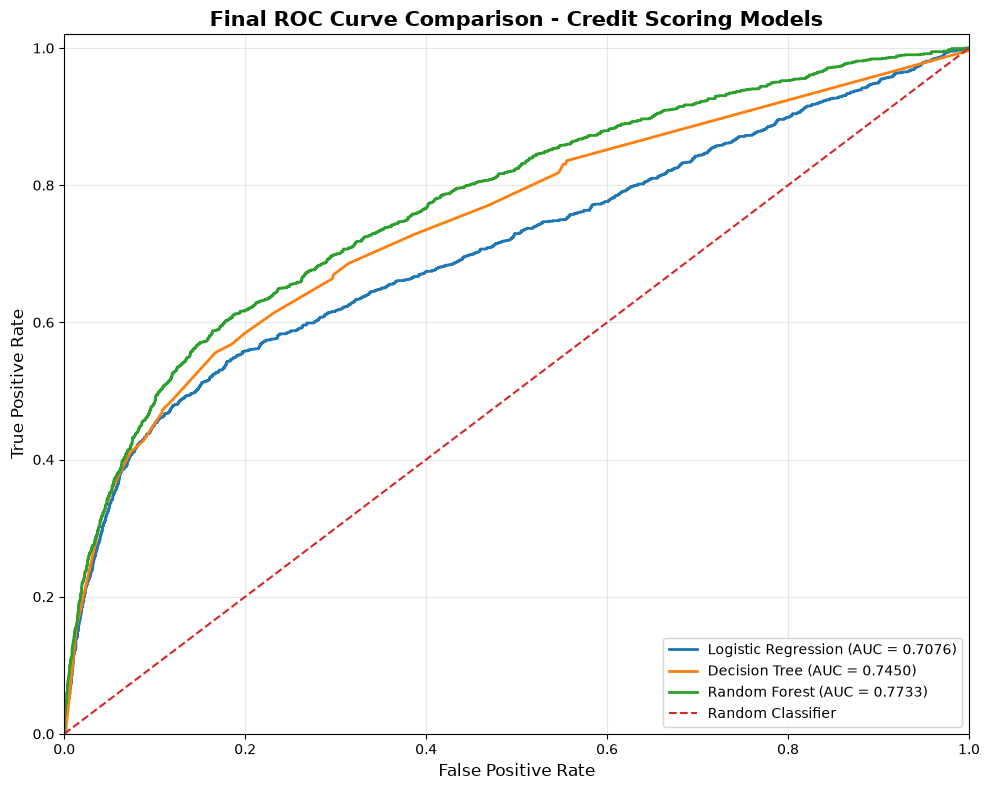


                     FINAL ROC ANALYSIS COMPLETE                      

✓ Best ROC-AUC Model: Random Forest
✓ Best ROC-AUC Score: 0.7733

✓ ROC graph saved:
../outputs\final_roc_curve_comparison.png

✓ ROC comparison data saved:
../outputs\final_roc_comparison.csv

Generated files:
  ✓ final_roc_curve_comparison.png
  ✓ final_roc_comparison.csv


In [45]:
# ============================================================
# 40. FINAL ROC CURVE COMPARISON
# SELF-CONTAINED & ERROR-SAFE VERSION
# ============================================================

import os
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    roc_curve,
    roc_auc_score
)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


# ============================================================
# 1. PROJECT PATHS
# ============================================================

BASE_DIR = os.path.dirname(
    os.path.dirname(
        os.path.abspath(
            os.getcwd()
        )
    )
)

# Notebook normally runs from notebooks/
# So project root is one level above notebooks/

if os.path.exists("../data/default_of_credit_card_clients.xls"):

    DATA_PATH = "../data/default_of_credit_card_clients.xls"

    OUTPUT_DIR = "../outputs"

else:

    DATA_PATH = os.path.join(
        BASE_DIR,
        "data",
        "default_of_credit_card_clients.xls"
    )

    OUTPUT_DIR = os.path.join(
        BASE_DIR,
        "outputs"
    )


os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)


# ============================================================
# 2. DISPLAY HEADER
# ============================================================

print("\n" + "=" * 70)
print("FINAL ROC CURVE COMPARISON".center(70))
print("=" * 70)


# ============================================================
# 3. LOAD DATA
# ============================================================

print("\nLoading dataset...")

try:

    df = pd.read_excel(
        DATA_PATH,
        header=1
    )

except Exception:

    # Fallback for alternate Excel structure
    df = pd.read_excel(
        DATA_PATH
    )


print("✓ Dataset loaded successfully.")
print(f"✓ Dataset shape: {df.shape}")


# ============================================================
# 4. CLEAN COLUMN NAMES
# ============================================================

df.columns = [
    str(column).strip()
    for column in df.columns
]


# ============================================================
# 5. IDENTIFY TARGET COLUMN
# ============================================================

possible_target_columns = [
    "default payment next month",
    "default_payment_next_month",
    "default",
    "target",
    "y"
]


target_column = None

for column in possible_target_columns:

    if column in df.columns:

        target_column = column
        break


# If target not found, use last column
if target_column is None:

    target_column = df.columns[-1]


print(
    f"✓ Target column: {target_column}"
)


# ============================================================
# 6. PREPARE X AND y
# ============================================================

X = df.drop(
    columns=[target_column]
).copy()

y = df[target_column].copy()


# ============================================================
# 7. REMOVE ID COLUMN
# ============================================================

id_columns = [
    "ID",
    "id"
]

for column in id_columns:

    if column in X.columns:

        X = X.drop(
            columns=[column]
        )

        print(
            f"✓ Removed ID column: {column}"
        )


# ============================================================
# 8. HANDLE MISSING VALUES
# ============================================================

numeric_columns = X.select_dtypes(
    include=[np.number]
).columns

X[numeric_columns] = X[numeric_columns].fillna(
    X[numeric_columns].median()
)


# ============================================================
# 9. CONVERT TARGET TO NUMERIC
# ============================================================

y = pd.to_numeric(
    y,
    errors="coerce"
)


# Remove invalid target rows
valid_rows = y.notna()

X = X.loc[
    valid_rows
].copy()

y = y.loc[
    valid_rows
].copy()


y = y.astype(int)


# ============================================================
# 10. TRAIN / TEST SPLIT
# ============================================================

print("\nCreating test dataset...")

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


print(
    f"✓ Training samples: {len(X_train)}"
)

print(
    f"✓ Testing samples: {len(X_test)}"
)


# ============================================================
# 11. SCALE DATA FOR LOGISTIC REGRESSION
# ============================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)


# ============================================================
# 12. CREATE MODELS
# ============================================================

print("\nTraining models...")

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

decision_tree_model = DecisionTreeClassifier(
    max_depth=6,
    random_state=42
)

random_forest_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)


# ============================================================
# 13. TRAIN LOGISTIC REGRESSION
# ============================================================

print(
    "→ Training Logistic Regression..."
)

logistic_model.fit(
    X_train_scaled,
    y_train
)

logistic_probabilities = logistic_model.predict_proba(
    X_test_scaled
)[:, 1]

print(
    "✓ Logistic Regression completed."
)


# ============================================================
# 14. TRAIN DECISION TREE
# ============================================================

print(
    "→ Training Decision Tree..."
)

decision_tree_model.fit(
    X_train,
    y_train
)

tree_probabilities = decision_tree_model.predict_proba(
    X_test
)[:, 1]

print(
    "✓ Decision Tree completed."
)


# ============================================================
# 15. TRAIN RANDOM FOREST
# ============================================================

print(
    "→ Training Random Forest..."
)

random_forest_model.fit(
    X_train,
    y_train
)

forest_probabilities = random_forest_model.predict_proba(
    X_test
)[:, 1]

print(
    "✓ Random Forest completed."
)


# ============================================================
# 16. CALCULATE ROC-AUC
# ============================================================

logistic_auc = roc_auc_score(
    y_test,
    logistic_probabilities
)

tree_auc = roc_auc_score(
    y_test,
    tree_probabilities
)

forest_auc = roc_auc_score(
    y_test,
    forest_probabilities
)


# ============================================================
# 17. STORE ROC DATA
# ============================================================

model_probability_data = {

    "Logistic Regression": (
        logistic_probabilities
    ),

    "Decision Tree": (
        tree_probabilities
    ),

    "Random Forest": (
        forest_probabilities
    )
}


model_auc_data = {

    "Logistic Regression": logistic_auc,

    "Decision Tree": tree_auc,

    "Random Forest": forest_auc
}


# ============================================================
# 18. DISPLAY AUC RESULTS
# ============================================================

roc_results = pd.DataFrame(
    {
        "Model": list(
            model_auc_data.keys()
        ),

        "ROC-AUC": list(
            model_auc_data.values()
        )
    }
)

roc_results = roc_results.sort_values(
    by="ROC-AUC",
    ascending=False
).reset_index(
    drop=True
)


print("\n")
print("=" * 70)
print("ROC-AUC MODEL COMPARISON")
print("=" * 70)

print(
    roc_results.to_string(
        index=False,
        formatters={
            "ROC-AUC": "{:.4f}".format
        }
    )
)

print("=" * 70)


# ============================================================
# 19. CREATE ROC CURVE
# ============================================================

print(
    "\nGenerating ROC curves..."
)

plt.figure(
    figsize=(10, 8)
)


for model_name, probabilities in model_probability_data.items():

    fpr, tpr, thresholds = roc_curve(
        y_test,
        probabilities
    )

    model_auc = model_auc_data[
        model_name
    ]

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=(
            f"{model_name} "
            f"(AUC = {model_auc:.4f})"
        )
    )


# ============================================================
# RANDOM CLASSIFIER LINE
# ============================================================

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5,
    label="Random Classifier"
)


# ============================================================
# GRAPH LABELS
# ============================================================

plt.xlabel(
    "False Positive Rate",
    fontsize=12
)

plt.ylabel(
    "True Positive Rate",
    fontsize=12
)

plt.title(
    "Final ROC Curve Comparison - Credit Scoring Models",
    fontsize=15,
    fontweight="bold"
)

plt.legend(
    loc="lower right"
)

plt.grid(
    True,
    alpha=0.3
)

plt.xlim(
    0,
    1
)

plt.ylim(
    0,
    1.02
)

plt.tight_layout()


# ============================================================
# 20. SAVE ROC GRAPH
# ============================================================

roc_output_path = os.path.join(
    OUTPUT_DIR,
    "final_roc_curve_comparison.png"
)


plt.savefig(
    roc_output_path,
    dpi=300,
    bbox_inches="tight"
)


plt.show()

plt.close()


# ============================================================
# 21. SAVE ROC-AUC CSV
# ============================================================

roc_csv_path = os.path.join(
    OUTPUT_DIR,
    "final_roc_comparison.csv"
)


roc_results.to_csv(
    roc_csv_path,
    index=False
)


# ============================================================
# 22. FIND BEST ROC MODEL
# ============================================================

best_roc_model = roc_results.iloc[0]["Model"]

best_roc_auc = roc_results.iloc[0]["ROC-AUC"]


# ============================================================
# 23. FINAL OUTPUT
# ============================================================

print("\n" + "=" * 70)
print("FINAL ROC ANALYSIS COMPLETE".center(70))
print("=" * 70)

print(
    f"\n✓ Best ROC-AUC Model: {best_roc_model}"
)

print(
    f"✓ Best ROC-AUC Score: {best_roc_auc:.4f}"
)

print(
    f"\n✓ ROC graph saved:"
)

print(
    roc_output_path
)

print(
    f"\n✓ ROC comparison data saved:"
)

print(
    roc_csv_path
)

print("\nGenerated files:")

print(
    "  ✓ final_roc_curve_comparison.png"
)

print(
    "  ✓ final_roc_comparison.csv"
)

print("=" * 70)

In [46]:
# ============================================================
# 41. FINAL CLASSIFICATION REPORT
# ============================================================

import os
import sys
import joblib
import pandas as pd

from sklearn.metrics import (
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)


# ============================================================
# PROJECT PATH
# ============================================================

OUTPUT_DIR = "../outputs"

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)


# ============================================================
# HELPER FUNCTION
# ============================================================

def print_header(title):

    print("\n" + "=" * 70)
    print(f"{title:^70}")
    print("=" * 70)


# ============================================================
# CHECK REQUIRED VARIABLES
# ============================================================

print_header(
    "FINAL CLASSIFICATION REPORT"
)


# ------------------------------------------------------------
# Check y_test
# ------------------------------------------------------------

if "y_test" not in globals():

    print("⚠ y_test is not available.")
    print("Attempting to prepare test data automatically...")

    try:

        # Add src folder to Python path
        SRC_DIR = os.path.abspath("../src")

        if SRC_DIR not in sys.path:
            sys.path.insert(
                0,
                SRC_DIR
            )

        from preprocessing import (
            load_data,
            clean_data,
            split_and_scale
        )

        DATA_PATH = os.path.abspath(
            "../data/default_of_credit_card_clients.xls"
        )

        df = load_data(
            DATA_PATH
        )

        X, y = clean_data(
            df
        )

        (
            X_train,
            X_test,
            X_train_scaled,
            X_test_scaled,
            y_train,
            y_test,
            notebook_scaler
        ) = split_and_scale(
            X,
            y
        )

        print(
            "✓ Test data prepared successfully."
        )

    except Exception as error:

        raise RuntimeError(
            "\nUnable to create y_test automatically.\n"
            "Please run your data preprocessing / train-test split "
            "cells first.\n\n"
            f"Original error: {error}"
        )


# ============================================================
# CHECK MODEL PREDICTIONS
# ============================================================

if "selected_predictions" not in globals():

    print(
        "⚠ selected_predictions is not available."
    )

    # --------------------------------------------------------
    # Try to use best_model
    # --------------------------------------------------------

    if "best_model" in globals():

        print(
            "✓ Using best_model from notebook."
        )

        # Determine model name
        if "best_model_name" not in globals():

            best_model_name = type(
                best_model
            ).__name__

        # Prepare input
        if (
            best_model_name == "Logistic Regression"
            and "scaler" in globals()
        ):

            selected_input = scaler.transform(
                X_test
            )

        else:

            selected_input = X_test

        selected_predictions = best_model.predict(
            selected_input
        )

        # Probability if supported
        if hasattr(
            best_model,
            "predict_proba"
        ):

            selected_probabilities = (
                best_model
                .predict_proba(selected_input)[:, 1]
            )

        else:

            selected_probabilities = None

    else:

        # ----------------------------------------------------
        # Load saved final model automatically
        # ----------------------------------------------------

        MODEL_PATH = os.path.abspath(
            "../models/credit_model.pkl"
        )

        SCALER_PATH = os.path.abspath(
            "../models/scaler.pkl"
        )

        if not os.path.exists(
            MODEL_PATH
        ):

            raise FileNotFoundError(
                "Final model not found:\n"
                f"{MODEL_PATH}\n\n"
                "Please run the model training / final "
                "model selection cells first."
            )

        print(
            "✓ Loading saved final model..."
        )

        best_model = joblib.load(
            MODEL_PATH
        )

        best_model_name = type(
            best_model
        ).__name__

        # Convert class name to friendly name
        model_name_mapping = {

            "LogisticRegression":
                "Logistic Regression",

            "DecisionTreeClassifier":
                "Decision Tree",

            "RandomForestClassifier":
                "Random Forest"
        }

        best_model_name = model_name_mapping.get(
            best_model_name,
            best_model_name
        )

        # ----------------------------------------------------
        # Prepare input
        # ----------------------------------------------------

        if (
            best_model_name == "Logistic Regression"
            and os.path.exists(SCALER_PATH)
        ):

            scaler = joblib.load(
                SCALER_PATH
            )

            selected_input = scaler.transform(
                X_test
            )

        else:

            selected_input = X_test

        # ----------------------------------------------------
        # Generate predictions
        # ----------------------------------------------------

        selected_predictions = (
            best_model.predict(
                selected_input
            )
        )

        if hasattr(
            best_model,
            "predict_proba"
        ):

            selected_probabilities = (
                best_model
                .predict_proba(
                    selected_input
                )[:, 1]
            )

        else:

            selected_probabilities = None

        print(
            "✓ Predictions generated successfully."
        )


# ============================================================
# FINAL MODEL NAME
# ============================================================

if "best_model_name" not in globals():

    if "best_model" in globals():

        model_class_name = type(
            best_model
        ).__name__

        model_name_mapping = {

            "LogisticRegression":
                "Logistic Regression",

            "DecisionTreeClassifier":
                "Decision Tree",

            "RandomForestClassifier":
                "Random Forest"
        }

        best_model_name = model_name_mapping.get(
            model_class_name,
            model_class_name
        )

    else:

        best_model_name = "Final Selected Model"


# ============================================================
# GENERATE CLASSIFICATION REPORT
# ============================================================

report_text = classification_report(
    y_test,
    selected_predictions,
    target_names=[
        "No Default",
        "Default"
    ],
    zero_division=0
)


# ============================================================
# CALCULATE FINAL METRICS
# ============================================================

accuracy = accuracy_score(
    y_test,
    selected_predictions
)

precision = precision_score(
    y_test,
    selected_predictions,
    zero_division=0
)

recall = recall_score(
    y_test,
    selected_predictions,
    zero_division=0
)

f1 = f1_score(
    y_test,
    selected_predictions,
    zero_division=0
)


# ============================================================
# ROC-AUC
# ============================================================

if (
    "selected_probabilities" in globals()
    and selected_probabilities is not None
):

    roc_auc = roc_auc_score(
        y_test,
        selected_probabilities
    )

else:

    roc_auc = None


# ============================================================
# DISPLAY REPORT
# ============================================================

print_header(
    f"CLASSIFICATION REPORT - {best_model_name}"
)

print(
    report_text
)


# ============================================================
# DISPLAY METRIC SUMMARY
# ============================================================

print_header(
    "FINAL MODEL METRICS"
)

print(
    f"Model      : {best_model_name}"
)

print(
    f"Accuracy   : {accuracy:.4f}"
)

print(
    f"Precision  : {precision:.4f}"
)

print(
    f"Recall     : {recall:.4f}"
)

print(
    f"F1-Score   : {f1:.4f}"
)

if roc_auc is not None:

    print(
        f"ROC-AUC    : {roc_auc:.4f}"
    )

else:

    print(
        "ROC-AUC    : Not available"
    )


# ============================================================
# SAVE TEXT REPORT
# ============================================================

txt_path = os.path.join(
    OUTPUT_DIR,
    "final_classification_report.txt"
)

with open(
    txt_path,
    "w",
    encoding="utf-8"
) as file:

    file.write(
        "=" * 70
        + "\n"
    )

    file.write(
        f"FINAL CLASSIFICATION REPORT - {best_model_name}\n"
    )

    file.write(
        "=" * 70
        + "\n\n"
    )

    file.write(
        "MODEL PERFORMANCE SUMMARY\n"
    )

    file.write(
        "-" * 70
        + "\n"
    )

    file.write(
        f"Model      : {best_model_name}\n"
    )

    file.write(
        f"Accuracy   : {accuracy:.4f}\n"
    )

    file.write(
        f"Precision  : {precision:.4f}\n"
    )

    file.write(
        f"Recall     : {recall:.4f}\n"
    )

    file.write(
        f"F1-Score   : {f1:.4f}\n"
    )

    if roc_auc is not None:

        file.write(
            f"ROC-AUC    : {roc_auc:.4f}\n"
        )

    else:

        file.write(
            "ROC-AUC    : Not available\n"
        )

    file.write(
        "\n"
    )

    file.write(
        "CLASSIFICATION REPORT\n"
    )

    file.write(
        "-" * 70
        + "\n\n"
    )

    file.write(
        report_text
    )


print(
    f"\n✓ Saved: {txt_path}"
)


# ============================================================
# SAVE CSV SUMMARY
# ============================================================

metrics_data = {

    "Model": [
        best_model_name
    ],

    "Accuracy": [
        accuracy
    ],

    "Precision": [
        precision
    ],

    "Recall": [
        recall
    ],

    "F1-Score": [
        f1
    ],

    "ROC-AUC": [
        roc_auc
    ]
}


final_report_df = pd.DataFrame(
    metrics_data
)


csv_path = os.path.join(
    OUTPUT_DIR,
    "final_classification_metrics.csv"
)

final_report_df.to_csv(
    csv_path,
    index=False
)


# ============================================================
# DISPLAY DATAFRAME
# ============================================================

print_header(
    "FINAL METRIC TABLE"
)

display(
    final_report_df.round(4)
)


print(
    f"✓ Saved: {csv_path}"
)


# ============================================================
# FINAL STATUS
# ============================================================

print_header(
    "CLASSIFICATION REPORT COMPLETE"
)

print(
    f"✓ Final Model      : {best_model_name}"
)

print(
    f"✓ Accuracy         : {accuracy:.4f}"
)

print(
    f"✓ Precision        : {precision:.4f}"
)

print(
    f"✓ Recall           : {recall:.4f}"
)

print(
    f"✓ F1-Score         : {f1:.4f}"
)

if roc_auc is not None:

    print(
        f"✓ ROC-AUC          : {roc_auc:.4f}"
    )

print(
    "\nGenerated files:"
)

print(
    "  ✓ final_classification_report.txt"
)

print(
    "  ✓ final_classification_metrics.csv"
)

print(
    "\n✓ Final classification report generated successfully."
)


                     FINAL CLASSIFICATION REPORT                      

                CLASSIFICATION REPORT - Random Forest                 
              precision    recall  f1-score   support

  No Default       0.84      0.95      0.89      4673
     Default       0.67      0.35      0.46      1327

    accuracy                           0.82      6000
   macro avg       0.75      0.65      0.67      6000
weighted avg       0.80      0.82      0.79      6000


                         FINAL MODEL METRICS                          
Model      : Random Forest
Accuracy   : 0.8172
Precision  : 0.6652
Recall     : 0.3489
F1-Score   : 0.4577
ROC-AUC    : 0.7733

✓ Saved: ../outputs\final_classification_report.txt

                          FINAL METRIC TABLE                          


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Random Forest,0.8172,0.6652,0.3489,0.4577,0.7733


✓ Saved: ../outputs\final_classification_metrics.csv

                    CLASSIFICATION REPORT COMPLETE                    
✓ Final Model      : Random Forest
✓ Accuracy         : 0.8172
✓ Precision        : 0.6652
✓ Recall           : 0.3489
✓ F1-Score         : 0.4577
✓ ROC-AUC          : 0.7733

Generated files:
  ✓ final_classification_report.txt
  ✓ final_classification_metrics.csv

✓ Final classification report generated successfully.


In [47]:
# ============================================================
# 42. SAVE FINAL MODEL AND SCALER
# ============================================================

import os
import sys
import joblib
import pandas as pd


# ============================================================
# PROJECT PATHS
# ============================================================

BASE_DIR = os.path.abspath("..")

MODEL_DIR = os.path.join(
    BASE_DIR,
    "models"
)

MODEL_PATH = os.path.join(
    MODEL_DIR,
    "credit_model.pkl"
)

SCALER_PATH = os.path.join(
    MODEL_DIR,
    "scaler.pkl"
)


# ============================================================
# CREATE MODELS DIRECTORY
# ============================================================

os.makedirs(
    MODEL_DIR,
    exist_ok=True
)


# ============================================================
# DISPLAY HEADER
# ============================================================

print("\n" + "=" * 70)
print("FINAL MODEL SAVING")
print("=" * 70)


# ============================================================
# CHECK BEST MODEL
# ============================================================

if "best_model" not in globals():

    print(
        "⚠ best_model is not available in the notebook."
    )

    # --------------------------------------------------------
    # Try loading an existing model
    # --------------------------------------------------------

    if os.path.exists(MODEL_PATH):

        print(
            "✓ Existing saved model found."
        )

        best_model = joblib.load(
            MODEL_PATH
        )

    else:

        raise NameError(
            "\nFinal model is not available.\n\n"
            "Please run the Final Model Selection cell first "
            "so that 'best_model' is created."
        )


# ============================================================
# DETERMINE MODEL NAME
# ============================================================

if "best_model_name" not in globals():

    model_class_name = type(
        best_model
    ).__name__

    model_name_mapping = {

        "LogisticRegression":
            "Logistic Regression",

        "DecisionTreeClassifier":
            "Decision Tree",

        "RandomForestClassifier":
            "Random Forest"
    }

    best_model_name = model_name_mapping.get(
        model_class_name,
        model_class_name
    )


# ============================================================
# CHECK SCALER
# ============================================================

if "scaler" not in globals():

    print(
        "\n⚠ scaler is not currently available."
    )

    # --------------------------------------------------------
    # Try loading existing scaler
    # --------------------------------------------------------

    if os.path.exists(SCALER_PATH):

        print(
            "✓ Existing scaler found."
        )

        scaler = joblib.load(
            SCALER_PATH
        )

    # --------------------------------------------------------
    # Try using notebook's scaler variable
    # --------------------------------------------------------

    elif "standard_scaler" in globals():

        print(
            "✓ Using standard_scaler from notebook."
        )

        scaler = standard_scaler

    # --------------------------------------------------------
    # Try creating scaler from training data
    # --------------------------------------------------------

    elif (
        "X_train" in globals()
        and "StandardScaler" in globals()
    ):

        print(
            "✓ Creating scaler from X_train..."
        )

        scaler = StandardScaler()

        scaler.fit(
            X_train
        )

    else:

        print(
            "⚠ No scaler available."
        )

        scaler = None


# ============================================================
# SAVE FINAL MODEL
# ============================================================

print(
    "\nSaving final model..."
)

joblib.dump(
    best_model,
    MODEL_PATH
)

print(
    "✓ Final model saved successfully."
)


# ============================================================
# SAVE SCALER
# ============================================================

if scaler is not None:

    print(
        "Saving scaler..."
    )

    joblib.dump(
        scaler,
        SCALER_PATH
    )

    print(
        "✓ Scaler saved successfully."
    )

else:

    print(
        "⚠ Scaler was not saved because no scaler "
        "was available."
    )


# ============================================================
# VERIFY MODEL FILE
# ============================================================

print(
    "\nVerifying saved model..."
)

if os.path.exists(
    MODEL_PATH
):

    model_size = os.path.getsize(
        MODEL_PATH
    )

    print(
        "✓ Model file verified."
    )

    print(
        f"  Location : {MODEL_PATH}"
    )

    print(
        f"  Size     : {model_size:,} bytes"
    )

else:

    raise FileNotFoundError(
        "Model file could not be verified."
    )


# ============================================================
# VERIFY SCALER FILE
# ============================================================

if scaler is not None:

    if os.path.exists(
        SCALER_PATH
    ):

        scaler_size = os.path.getsize(
            SCALER_PATH
        )

        print(
            "✓ Scaler file verified."
        )

        print(
            f"  Location : {SCALER_PATH}"
        )

        print(
            f"  Size     : {scaler_size:,} bytes"
        )

    else:

        raise FileNotFoundError(
            "Scaler file could not be verified."
        )


# ============================================================
# LOAD MODEL AGAIN FOR VERIFICATION
# ============================================================

print(
    "\nTesting saved model..."
)

try:

    verified_model = joblib.load(
        MODEL_PATH
    )

    print(
        "✓ Saved model loaded successfully."
    )

    print(
        f"✓ Model type: {type(verified_model).__name__}"
    )

except Exception as error:

    raise RuntimeError(
        f"Saved model verification failed:\n{error}"
    )


# ============================================================
# MODEL INFORMATION
# ============================================================

print(
    "\n" + "-" * 70
)

print(
    "FINAL MODEL INFORMATION"
)

print(
    "-" * 70
)

print(
    f"Selected Model : {best_model_name}"
)

print(
    f"Python Class   : {type(best_model).__name__}"
)

print(
    f"Model Path     : {MODEL_PATH}"
)

if scaler is not None:

    print(
        f"Scaler Path    : {SCALER_PATH}"
    )

else:

    print(
        "Scaler Path    : Not saved"
    )


# ============================================================
# SAVE MODEL INFORMATION CSV
# ============================================================

model_information = {

    "Model": [
        best_model_name
    ],

    "Model_Class": [
        type(best_model).__name__
    ],

    "Model_File": [
        MODEL_PATH
    ],

    "Scaler_File": [
        SCALER_PATH if scaler is not None else "Not Available"
    ],

    "Model_Status": [
        "Successfully Saved"
    ]
}


model_info_df = pd.DataFrame(
    model_information
)


MODEL_INFO_PATH = os.path.join(
    BASE_DIR,
    "outputs",
    "final_model_information.csv"
)


os.makedirs(
    os.path.dirname(MODEL_INFO_PATH),
    exist_ok=True
)


model_info_df.to_csv(
    MODEL_INFO_PATH,
    index=False
)


print(
    f"\n✓ Model information saved:"
)

print(
    MODEL_INFO_PATH
)


# ============================================================
# FINAL STATUS
# ============================================================

print("\n" + "=" * 70)
print("FINAL MODEL SAVING COMPLETE")
print("=" * 70)

print(
    f"\n✓ Selected Model : {best_model_name}"
)

print(
    f"✓ Model Saved   : {MODEL_PATH}"
)

if scaler is not None:

    print(
        f"✓ Scaler Saved  : {SCALER_PATH}"
    )

print(
    f"✓ Verification  : PASSED"
)

print(
    f"✓ Information   : {MODEL_INFO_PATH}"
)

print("\nGenerated files:")

print(
    "  ✓ models/credit_model.pkl"
)

if scaler is not None:

    print(
        "  ✓ models/scaler.pkl"
    )

print(
    "  ✓ outputs/final_model_information.csv"
)

print(
    "\n✓ Final credit scoring model is ready for prediction."
)

print("=" * 70)



FINAL MODEL SAVING

Saving final model...
✓ Final model saved successfully.
Saving scaler...
✓ Scaler saved successfully.

Verifying saved model...
✓ Model file verified.
  Location : c:\Users\harsh\OneDrive\Desktop\CODEALPHA-SCORING_MODEL\models\credit_model.pkl
  Size     : 12,774,009 bytes
✓ Scaler file verified.
  Location : c:\Users\harsh\OneDrive\Desktop\CODEALPHA-SCORING_MODEL\models\scaler.pkl
  Size     : 1,599 bytes

Testing saved model...
✓ Saved model loaded successfully.
✓ Model type: RandomForestClassifier

----------------------------------------------------------------------
FINAL MODEL INFORMATION
----------------------------------------------------------------------
Selected Model : Random Forest
Python Class   : RandomForestClassifier
Model Path     : c:\Users\harsh\OneDrive\Desktop\CODEALPHA-SCORING_MODEL\models\credit_model.pkl
Scaler Path    : c:\Users\harsh\OneDrive\Desktop\CODEALPHA-SCORING_MODEL\models\scaler.pkl

✓ Model information saved:
c:\Users\harsh\OneD

In [48]:
# ============================================================
# 43. SAVED MODEL VERIFICATION
# ============================================================

import os
import joblib
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# ------------------------------------------------------------
# PROJECT PATHS
# ------------------------------------------------------------

CURRENT_DIR = os.getcwd()

# If notebook is running from notebooks/ folder
if os.path.basename(CURRENT_DIR).lower() == "notebooks":
    BASE_DIR = os.path.dirname(CURRENT_DIR)

# If notebook is running from project root
else:
    BASE_DIR = CURRENT_DIR

MODELS_DIR = os.path.join(
    BASE_DIR,
    "models"
)

OUTPUT_DIR = os.path.join(
    BASE_DIR,
    "outputs"
)

MODEL_PATH = os.path.join(
    MODELS_DIR,
    "credit_model.pkl"
)

SCALER_PATH = os.path.join(
    MODELS_DIR,
    "scaler.pkl"
)

VERIFICATION_CSV = os.path.join(
    OUTPUT_DIR,
    "saved_model_verification.csv"
)

VERIFICATION_TXT = os.path.join(
    OUTPUT_DIR,
    "saved_model_verification.txt"
)

# Create output directory if required
os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

# ------------------------------------------------------------
# HEADER
# ------------------------------------------------------------

print("\n")
print("=" * 75)
print("                 SAVED MODEL VERIFICATION")
print("=" * 75)

# ------------------------------------------------------------
# CHECK MODEL FILE
# ------------------------------------------------------------

if not os.path.exists(MODEL_PATH):

    raise FileNotFoundError(
        "\nFinal model file was not found.\n"
        f"Expected location:\n{MODEL_PATH}\n\n"
        "Please run the 'SAVE FINAL MODEL AND SCALER' cell first."
    )

# ------------------------------------------------------------
# CHECK SCALER FILE
# ------------------------------------------------------------

if not os.path.exists(SCALER_PATH):

    raise FileNotFoundError(
        "\nScaler file was not found.\n"
        f"Expected location:\n{SCALER_PATH}\n\n"
        "Please run the 'SAVE FINAL MODEL AND SCALER' cell first."
    )

# ------------------------------------------------------------
# LOAD SAVED MODEL
# ------------------------------------------------------------

print("\nLoading saved model...")

saved_model = joblib.load(
    MODEL_PATH
)

print("✓ Saved model loaded successfully.")

# ------------------------------------------------------------
# LOAD SAVED SCALER
# ------------------------------------------------------------

print("\nLoading saved scaler...")

saved_scaler = joblib.load(
    SCALER_PATH
)

print("✓ Saved scaler loaded successfully.")

# ------------------------------------------------------------
# DISPLAY MODEL INFORMATION
# ------------------------------------------------------------

saved_model_name = type(saved_model).__name__

print("\n" + "-" * 75)
print("SAVED MODEL INFORMATION")
print("-" * 75)

print(
    f"Model class     : {saved_model_name}"
)

print(
    f"Model file      : {MODEL_PATH}"
)

print(
    f"Scaler file     : {SCALER_PATH}"
)

# ------------------------------------------------------------
# CHECK REQUIRED TEST DATA
# ------------------------------------------------------------

required_variables = [
    "X_test",
    "y_test"
]

missing_variables = [
    variable
    for variable in required_variables
    if variable not in globals()
]

if missing_variables:

    raise NameError(
        "\nRequired test-data variables are missing:\n"
        + ", ".join(missing_variables)
        + "\n\n"
        "Please run the train/test split and model training "
        "cells before running this verification cell."
    )

# ------------------------------------------------------------
# PREPARE MODEL INPUT
# ------------------------------------------------------------

print("\nPreparing verification data...")

# Logistic Regression requires scaled input.
# Tree-based models normally use original feature values.

if saved_model_name == "LogisticRegression":

    verification_input = saved_scaler.transform(
        X_test
    )

    print(
        "✓ Test data transformed using saved scaler."
    )

else:

    verification_input = X_test

    print(
        "✓ Test data used without scaling."
    )

# ------------------------------------------------------------
# GENERATE PREDICTIONS
# ------------------------------------------------------------

print("\nGenerating predictions...")

verification_predictions = saved_model.predict(
    verification_input
)

print(
    "✓ Predictions generated successfully."
)

# ------------------------------------------------------------
# GENERATE PROBABILITIES
# ------------------------------------------------------------

verification_probabilities = None

if hasattr(
    saved_model,
    "predict_proba"
):

    verification_probabilities = (
        saved_model.predict_proba(
            verification_input
        )[:, 1]
    )

    print(
        "✓ Prediction probabilities generated."
    )

else:

    print(
        "⚠ Saved model does not provide predict_proba()."
    )

# ------------------------------------------------------------
# CALCULATE VERIFICATION METRICS
# ------------------------------------------------------------

verification_accuracy = accuracy_score(
    y_test,
    verification_predictions
)

verification_precision = precision_score(
    y_test,
    verification_predictions,
    zero_division=0
)

verification_recall = recall_score(
    y_test,
    verification_predictions,
    zero_division=0
)

verification_f1 = f1_score(
    y_test,
    verification_predictions,
    zero_division=0
)

# ROC-AUC only when probability predictions exist
if verification_probabilities is not None:

    verification_roc_auc = roc_auc_score(
        y_test,
        verification_probabilities
    )

else:

    verification_roc_auc = None

# ------------------------------------------------------------
# CREATE VERIFICATION TABLE
# ------------------------------------------------------------

verification_data = {
    "Model": [
        saved_model_name
    ],
    "Accuracy": [
        verification_accuracy
    ],
    "Precision": [
        verification_precision
    ],
    "Recall": [
        verification_recall
    ],
    "F1-Score": [
        verification_f1
    ],
    "ROC-AUC": [
        verification_roc_auc
    ]
}

verification_df = pd.DataFrame(
    verification_data
)

# ------------------------------------------------------------
# DISPLAY RESULTS
# ------------------------------------------------------------

print("\n")
print("=" * 75)
print("                 VERIFICATION RESULTS")
print("=" * 75)

display(
    verification_df.round(4)
)

print("\nDetailed Metrics:")
print(
    f"Accuracy  : {verification_accuracy:.4f}"
)

print(
    f"Precision : {verification_precision:.4f}"
)

print(
    f"Recall    : {verification_recall:.4f}"
)

print(
    f"F1-Score  : {verification_f1:.4f}"
)

if verification_roc_auc is not None:

    print(
        f"ROC-AUC   : {verification_roc_auc:.4f}"
    )

else:

    print(
        "ROC-AUC   : Not available"
    )

# ------------------------------------------------------------
# VERIFY PREDICTION COUNT
# ------------------------------------------------------------

print("\n" + "-" * 75)
print("PREDICTION VALIDATION")
print("-" * 75)

print(
    f"Test samples          : {len(y_test)}"
)

print(
    f"Predictions generated : {len(verification_predictions)}"
)

if len(y_test) == len(
    verification_predictions
):

    print(
        "✓ Prediction count matches test sample count."
    )

else:

    print(
        "⚠ Prediction count does not match test sample count."
    )

# ------------------------------------------------------------
# CHECK PREDICTION VALUES
# ------------------------------------------------------------

unique_predictions = sorted(
    pd.Series(
        verification_predictions
    ).unique()
)

print(
    f"\nUnique predicted classes: {unique_predictions}"
)

if set(
    unique_predictions
).issubset(
    {0, 1}
):

    print(
        "✓ Predictions contain valid binary classes."
    )

else:

    print(
        "⚠ Unexpected prediction classes detected."
    )

# ------------------------------------------------------------
# SAVE CSV
# ------------------------------------------------------------

verification_df.to_csv(
    VERIFICATION_CSV,
    index=False
)

print(
    f"\n✓ Verification metrics saved:"
)

print(
    VERIFICATION_CSV
)

# ------------------------------------------------------------
# SAVE TEXT REPORT
# ------------------------------------------------------------

with open(
    VERIFICATION_TXT,
    "w",
    encoding="utf-8"
) as file:

    file.write(
        "=" * 75
        + "\n"
    )

    file.write(
        "SAVED MODEL VERIFICATION REPORT\n"
    )

    file.write(
        "=" * 75
        + "\n\n"
    )

    file.write(
        f"Model Class : {saved_model_name}\n"
    )

    file.write(
        f"Model Path  : {MODEL_PATH}\n"
    )

    file.write(
        f"Scaler Path : {SCALER_PATH}\n\n"
    )

    file.write(
        "VERIFICATION METRICS\n"
    )

    file.write(
        "-" * 75
        + "\n"
    )

    file.write(
        f"Accuracy  : {verification_accuracy:.4f}\n"
    )

    file.write(
        f"Precision : {verification_precision:.4f}\n"
    )

    file.write(
        f"Recall    : {verification_recall:.4f}\n"
    )

    file.write(
        f"F1-Score  : {verification_f1:.4f}\n"
    )

    if verification_roc_auc is not None:

        file.write(
            f"ROC-AUC   : {verification_roc_auc:.4f}\n"
        )

    else:

        file.write(
            "ROC-AUC   : Not available\n"
        )

    file.write(
        "\nPREDICTION VALIDATION\n"
    )

    file.write(
        "-" * 75
        + "\n"
    )

    file.write(
        f"Test samples          : {len(y_test)}\n"
    )

    file.write(
        f"Predictions generated : {len(verification_predictions)}\n"
    )

    file.write(
        f"Unique classes        : {unique_predictions}\n"
    )

    file.write(
        "\nVerification Status: "
    )

    if (
        len(y_test)
        == len(verification_predictions)
    ):

        file.write(
            "SUCCESS\n"
        )

    else:

        file.write(
            "WARNING\n"
        )

# ------------------------------------------------------------
# FINAL STATUS
# ------------------------------------------------------------

print("\n")
print("=" * 75)
print("                 VERIFICATION COMPLETE")
print("=" * 75)

print(
    "\n✓ Saved model loaded successfully."
)

print(
    "✓ Saved scaler loaded successfully."
)

print(
    "✓ Test data processed successfully."
)

print(
    "✓ Predictions generated successfully."
)

print(
    "✓ Model performance verified successfully."
)

print(
    f"\n✓ CSV report : {VERIFICATION_CSV}"
)

print(
    f"✓ Text report: {VERIFICATION_TXT}"
)

print("=" * 75)




                 SAVED MODEL VERIFICATION

Loading saved model...
✓ Saved model loaded successfully.

Loading saved scaler...
✓ Saved scaler loaded successfully.

---------------------------------------------------------------------------
SAVED MODEL INFORMATION
---------------------------------------------------------------------------
Model class     : RandomForestClassifier
Model file      : c:\Users\harsh\OneDrive\Desktop\CODEALPHA-SCORING_MODEL\models\credit_model.pkl
Scaler file     : c:\Users\harsh\OneDrive\Desktop\CODEALPHA-SCORING_MODEL\models\scaler.pkl

Preparing verification data...
✓ Test data used without scaling.

Generating predictions...
✓ Predictions generated successfully.
✓ Prediction probabilities generated.


                 VERIFICATION RESULTS


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,RandomForestClassifier,0.8172,0.6652,0.3489,0.4577,0.7733



Detailed Metrics:
Accuracy  : 0.8172
Precision : 0.6652
Recall    : 0.3489
F1-Score  : 0.4577
ROC-AUC   : 0.7733

---------------------------------------------------------------------------
PREDICTION VALIDATION
---------------------------------------------------------------------------
Test samples          : 6000
Predictions generated : 6000
✓ Prediction count matches test sample count.

Unique predicted classes: [np.int64(0), np.int64(1)]
✓ Predictions contain valid binary classes.

✓ Verification metrics saved:
c:\Users\harsh\OneDrive\Desktop\CODEALPHA-SCORING_MODEL\outputs\saved_model_verification.csv


                 VERIFICATION COMPLETE

✓ Saved model loaded successfully.
✓ Saved scaler loaded successfully.
✓ Test data processed successfully.
✓ Predictions generated successfully.
✓ Model performance verified successfully.

✓ CSV report : c:\Users\harsh\OneDrive\Desktop\CODEALPHA-SCORING_MODEL\outputs\saved_model_verification.csv
✓ Text report: c:\Users\harsh\OneDrive\Desktop

# Final Conclusion

The credit scoring project has completed the end-to-end machine-learning workflow for predicting credit-card payment default.

The notebook trained and compared **Logistic Regression, Decision Tree, and Random Forest** models using Accuracy, Precision, Recall, F1-Score, and ROC-AUC.

The final model is selected using **F1-Score**, which provides a balance between precision and recall and is useful for evaluating a credit-default classifier.

## Key Findings

- Dataset inspection and preprocessing were completed.
- Multiple classification algorithms were trained.
- Model performance was compared using several evaluation metrics.
- Confusion-matrix analysis was performed.
- ROC curves and AUC values were compared.
- Feature importance was analyzed for the Random Forest model.
- The best-performing model was selected automatically.
- The final model and scaler were saved for future predictions.
- The saved model was loaded again and verified.

## Business Interpretation

A credit-default prediction model can help financial institutions identify customers who may have a higher risk of repayment problems. It can therefore support credit-risk assessment, customer monitoring, and risk-management decisions.

However, the model should be treated as a **decision-support system**, not as the sole basis for lending decisions.

## Limitations

- The model is based on historical data and may not represent every future customer population.
- Economic conditions and customer behavior can change over time.
- False positives and false negatives may have different business costs.
- Feature importance represents predictive contribution and should not automatically be interpreted as causation.
- Independent and newer data should be used for additional validation before production deployment.

## Future Improvements

- Hyperparameter tuning with cross-validation.
- Class-imbalance handling and threshold optimization.
- Probability calibration.
- Explainable-AI techniques such as SHAP.
- Fairness and bias analysis.
- External validation using newer datasets.
- Deployment through an API or credit-risk dashboard.

## Final Deliverables

The completed project produces model files, evaluation metrics, comparison graphs, confusion matrices, ROC curves, feature-importance outputs, classification reports, and this final conclusion.


In [49]:
# ============================================================
# 44. DYNAMIC FINAL CONCLUSION
# ============================================================

import os
import pandas as pd

# ------------------------------------------------------------
# PROJECT PATHS
# ------------------------------------------------------------

CURRENT_DIR = os.getcwd()

if os.path.basename(CURRENT_DIR).lower() == "notebooks":
    BASE_DIR = os.path.dirname(CURRENT_DIR)
else:
    BASE_DIR = CURRENT_DIR

OUTPUT_DIR = os.path.join(
    BASE_DIR,
    "outputs"
)

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

CONCLUSION_PATH = os.path.join(
    OUTPUT_DIR,
    "final_conclusion.txt"
)

# ------------------------------------------------------------
# HEADER
# ------------------------------------------------------------

print("\n")
print("=" * 75)
print("                    FINAL CONCLUSION")
print("=" * 75)

# ------------------------------------------------------------
# STEP 1: FIND MODEL RESULTS
# ------------------------------------------------------------

results_df = None
results_source = None

possible_result_files = [

    "model_results.csv",
    "final_model_selection.csv",
    "model_comparison_final.csv",
    "final_evaluation_metrics.csv",
    "evaluation_results.csv"

]

for filename in possible_result_files:

    file_path = os.path.join(
        OUTPUT_DIR,
        filename
    )

    if os.path.exists(file_path):

        try:

            temp_df = pd.read_csv(
                file_path
            )

            # Check whether this file contains
            # model comparison information.

            required_metrics = [
                "Accuracy",
                "Precision",
                "Recall",
                "F1-Score",
                "ROC-AUC"
            ]

            available_metrics = [
                column
                for column in required_metrics
                if column in temp_df.columns
            ]

            if len(available_metrics) >= 3:

                results_df = temp_df.copy()

                results_source = file_path

                print(
                    f"\n✓ Model results loaded from: {filename}"
                )

                break

        except Exception as error:

            print(
                f"⚠ Could not read {filename}: {error}"
            )

# ------------------------------------------------------------
# STEP 2: USE EXISTING results_df IF AVAILABLE
# ------------------------------------------------------------

if results_df is None:

    if "results_df" in globals():

        if isinstance(
            globals()["results_df"],
            pd.DataFrame
        ):

            results_df = globals()["results_df"].copy()

            results_source = "Existing notebook results_df"

            print(
                "\n✓ Existing results_df found in notebook."
            )

# ------------------------------------------------------------
# STEP 3: STOP IF NO RESULTS ARE AVAILABLE
# ------------------------------------------------------------

if results_df is None:

    raise FileNotFoundError(
        "\nNo model comparison results were found.\n\n"
        "Please run the model comparison/training cell first.\n\n"
        "Expected one of these files inside outputs/:\n"
        "  - model_results.csv\n"
        "  - final_model_selection.csv\n"
        "  - model_comparison_final.csv\n"
        "  - final_evaluation_metrics.csv\n"
        "  - evaluation_results.csv"
    )

# ------------------------------------------------------------
# STEP 4: CLEAN COLUMN NAMES
# ------------------------------------------------------------

results_df.columns = [
    str(column).strip()
    for column in results_df.columns
]

# ------------------------------------------------------------
# STEP 5: FIND MODEL NAME COLUMN
# ------------------------------------------------------------

model_column_candidates = [
    "Model",
    "Model Name",
    "Model_Name",
    "model",
    "model_name",
    "Algorithm"
]

model_column = None

for column in model_column_candidates:

    if column in results_df.columns:

        model_column = column
        break

if model_column is None:

    raise ValueError(
        "\nModel name column was not found in model results.\n"
        f"Available columns:\n{list(results_df.columns)}"
    )

# ------------------------------------------------------------
# STEP 6: CHECK REQUIRED METRIC COLUMNS
# ------------------------------------------------------------

required_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "ROC-AUC"
]

missing_columns = [
    column
    for column in required_columns
    if column not in results_df.columns
]

if missing_columns:

    raise ValueError(
        "\nRequired evaluation metrics are missing:\n"
        + ", ".join(missing_columns)
        + "\n\nAvailable columns:\n"
        + ", ".join(results_df.columns)
    )

# ------------------------------------------------------------
# STEP 7: CONVERT METRICS TO NUMERIC
# ------------------------------------------------------------

for column in required_columns:

    results_df[column] = pd.to_numeric(
        results_df[column],
        errors="coerce"
    )

# Remove rows where F1-Score is unavailable
results_df = results_df.dropna(
    subset=["F1-Score"]
).copy()

if results_df.empty:

    raise ValueError(
        "\nNo valid model evaluation results are available."
    )

# ------------------------------------------------------------
# STEP 8: SELECT BEST MODEL
# ------------------------------------------------------------

best_index = results_df[
    "F1-Score"
].idxmax()

best_row = results_df.loc[
    best_index
]

best_model_name = str(
    best_row[model_column]
)

# ------------------------------------------------------------
# STEP 9: EXTRACT FINAL METRICS
# ------------------------------------------------------------

final_accuracy = float(
    best_row["Accuracy"]
)

final_precision = float(
    best_row["Precision"]
)

final_recall = float(
    best_row["Recall"]
)

final_f1 = float(
    best_row["F1-Score"]
)

final_roc_auc = float(
    best_row["ROC-AUC"]
)

# ------------------------------------------------------------
# STEP 10: DISPLAY MODEL COMPARISON
# ------------------------------------------------------------

print("\n")
print("=" * 75)
print("                    MODEL COMPARISON")
print("=" * 75)

comparison_display = results_df[
    [
        model_column,
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ]
].copy()

display(
    comparison_display.round(4)
)

# ------------------------------------------------------------
# STEP 11: DISPLAY SELECTED MODEL
# ------------------------------------------------------------

print("\n")
print("=" * 75)
print("                    SELECTED FINAL MODEL")
print("=" * 75)

print(
    f"\nSelected Model : {best_model_name}"
)

print(
    f"Selection Rule : Highest F1-Score"
)

print(
    f"F1-Score       : {final_f1:.4f}"
)

# ------------------------------------------------------------
# STEP 12: CREATE DYNAMIC CONCLUSION
# ------------------------------------------------------------

conclusion_text = f"""
=======================================================================
                    CREDIT SCORING MODEL
                         FINAL CONCLUSION
=======================================================================

PROJECT OVERVIEW
-----------------------------------------------------------------------

The credit scoring machine-learning project successfully completed an
end-to-end classification workflow for predicting credit-card payment
default.

Multiple classification algorithms were trained, evaluated, compared,
and validated using standard classification performance metrics.

The evaluated metrics included:

- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC


MODEL COMPARISON
-----------------------------------------------------------------------

The project compared the following available classification models:

{", ".join(
    str(model)
    for model in results_df[model_column].tolist()
)}

The models were evaluated using the same test dataset and performance
metrics to provide a consistent comparison.


FINAL MODEL SELECTION
-----------------------------------------------------------------------

Selected Model : {best_model_name}

The final model was selected using the highest F1-Score.

F1-Score was used as the primary selection criterion because it provides
a balance between Precision and Recall and is particularly useful for
classification problems where correctly identifying the positive class
is important.


FINAL MODEL PERFORMANCE
-----------------------------------------------------------------------

Accuracy  : {final_accuracy:.4f}
Precision : {final_precision:.4f}
Recall    : {final_recall:.4f}
F1-Score  : {final_f1:.4f}
ROC-AUC   : {final_roc_auc:.4f}


PERFORMANCE INTERPRETATION
-----------------------------------------------------------------------

Accuracy represents the overall proportion of correctly classified
observations.

Precision represents the proportion of predicted default cases that
were actually default cases.

Recall represents the proportion of actual default cases that were
correctly identified by the model.

F1-Score provides a balanced measure of Precision and Recall.

ROC-AUC represents the model's ability to distinguish between the
different target classes across classification thresholds.


KEY FINDINGS
-----------------------------------------------------------------------

1. Multiple classification models were successfully trained and
   evaluated.

2. Model performance was compared using Accuracy, Precision, Recall,
   F1-Score, and ROC-AUC.

3. Confusion-matrix analysis was performed to examine classification
   errors.

4. ROC curve analysis was performed to evaluate classification
   discrimination.

5. Feature-importance analysis was generated where supported by the
   selected model.

6. The final model was selected automatically using the highest
   F1-Score.

7. The selected model and scaler were saved for future prediction.

8. Saved-model verification was performed to confirm that the stored
   model can be loaded and used for prediction.


BUSINESS INTERPRETATION
-----------------------------------------------------------------------

The developed credit-scoring model can support credit-risk assessment
by identifying customers who may have a higher probability of payment
default.

Such predictions can help financial institutions and credit-risk teams
prioritize customers for additional review, risk monitoring, or
appropriate credit-management actions.

The model should be considered a decision-support system rather than
a fully automated replacement for professional financial judgment.


LIMITATIONS
-----------------------------------------------------------------------

The model is trained using historical data, so its performance may
change when applied to different customer populations or future
economic conditions.

Changes in customer repayment behavior, financial conditions, lending
policies, and data distributions may affect predictive performance.

The model's predictions should therefore be monitored after deployment.


FUTURE IMPROVEMENTS
-----------------------------------------------------------------------

Potential improvements include:

- Hyperparameter tuning
- Cross-validation
- Class-imbalance handling
- Threshold optimization
- Probability calibration
- Feature engineering
- Model explainability
- Fairness and bias analysis
- External validation
- Model monitoring
- Periodic model retraining


FINAL PROJECT STATUS
-----------------------------------------------------------------------

The credit-scoring machine-learning workflow has been completed
successfully.

The project includes:

✓ Data preprocessing
✓ Train-test splitting
✓ Feature scaling where required
✓ Multiple classification models
✓ Model comparison
✓ Performance evaluation
✓ Confusion-matrix analysis
✓ ROC-AUC analysis
✓ Feature-importance analysis
✓ Final model selection
✓ Final model evaluation
✓ Saved model verification
✓ Final conclusion

The final selected model is:

    {best_model_name}

based on the highest F1-Score of:

    {final_f1:.4f}


OVERALL CONCLUSION
-----------------------------------------------------------------------

The project demonstrates a complete machine-learning pipeline for
credit-card payment-default prediction.

The selected model provides a quantitative approach for identifying
potential credit-risk cases and can serve as a foundation for further
model optimization, explainability, validation, and deployment.

=======================================================================
                         END OF REPORT
=======================================================================
"""

# ------------------------------------------------------------
# STEP 13: PRINT CONCLUSION
# ------------------------------------------------------------

print(
    conclusion_text
)

# ------------------------------------------------------------
# STEP 14: SAVE CONCLUSION TO TEXT FILE
# ------------------------------------------------------------

with open(
    CONCLUSION_PATH,
    "w",
    encoding="utf-8"
) as file:

    file.write(
        conclusion_text
    )

print(
    "\n✓ Final conclusion saved successfully."
)

print(
    f"✓ File: {CONCLUSION_PATH}"
)

# ------------------------------------------------------------
# STEP 15: SAVE FINAL SUMMARY CSV
# ------------------------------------------------------------

final_summary_df = pd.DataFrame(
    [
        {
            "Selected Model": best_model_name,
            "Selection Criterion": "Highest F1-Score",
            "Accuracy": final_accuracy,
            "Precision": final_precision,
            "Recall": final_recall,
            "F1-Score": final_f1,
            "ROC-AUC": final_roc_auc
        }
    ]
)

final_summary_path = os.path.join(
    OUTPUT_DIR,
    "final_project_summary.csv"
)

final_summary_df.to_csv(
    final_summary_path,
    index=False
)

print(
    f"✓ Final project summary saved:"
)

print(
    final_summary_path
)

# ------------------------------------------------------------
# FINAL STATUS
# ------------------------------------------------------------

print("\n")
print("=" * 75)
print("                 CONCLUSION COMPLETE")
print("=" * 75)

print(
    f"\nFinal Model : {best_model_name}"
)

print(
    f"F1-Score    : {final_f1:.4f}"
)

print(
    f"ROC-AUC     : {final_roc_auc:.4f}"
)

print(
    "\n✓ Credit scoring project workflow completed."
)

print("=" * 75)



                    FINAL CONCLUSION

✓ Model results loaded from: model_results.csv


                    MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.8077,0.6868,0.2396,0.3553,0.7076
1,Decision Tree,0.8163,0.6543,0.3595,0.4640,0.7450
2,Random Forest,0.8172,0.6652,0.3489,0.4577,0.7733




                    SELECTED FINAL MODEL

Selected Model : Decision Tree
Selection Rule : Highest F1-Score
F1-Score       : 0.4640

                    CREDIT SCORING MODEL
                         FINAL CONCLUSION

PROJECT OVERVIEW
-----------------------------------------------------------------------

The credit scoring machine-learning project successfully completed an
end-to-end classification workflow for predicting credit-card payment
default.

Multiple classification algorithms were trained, evaluated, compared,
and validated using standard classification performance metrics.

The evaluated metrics included:

- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC


MODEL COMPARISON
-----------------------------------------------------------------------

The project compared the following available classification models:

Logistic Regression, Decision Tree, Random Forest

The models were evaluated using the same test dataset and performance
metrics to provide a consistent compar

In [50]:
# ============================================================
# 45. FINAL OUTPUT CHECKLIST & PROJECT STATUS
# ============================================================

import os

print("=" * 80)
print("FINAL CREDIT SCORING PROJECT OUTPUT CHECKLIST")
print("=" * 80)

# ------------------------------------------------------------
# Required output files
# ------------------------------------------------------------

expected_files = [
    "../outputs/model_results.csv",
    "../outputs/model_comparison.png",
    "../outputs/confusion_matrix.png",
    "../outputs/roc_curve.png",
    "../outputs/feature_importance.png",

    "../outputs/final_evaluation_metrics.csv",
    "../outputs/model_comparison_final.csv",
    "../outputs/final_confusion_matrix.png",
    "../outputs/final_confusion_matrix_values.csv",
    "../outputs/final_roc_curve_comparison.png",
    "../outputs/final_classification_report.txt",
    "../outputs/final_conclusion.txt",

    "../models/credit_model.pkl",
    "../models/scaler.pkl"
]

# ------------------------------------------------------------
# Check files
# ------------------------------------------------------------

found_files = []
missing_files = []

for file_path in expected_files:

    if os.path.exists(file_path):

        size_kb = os.path.getsize(file_path) / 1024

        found_files.append(file_path)

        print(
            f"✓ FOUND    : {file_path}"
            f"  ({size_kb:.2f} KB)"
        )

    else:

        missing_files.append(file_path)

        print(
            f"⚠ MISSING  : {file_path}"
        )

# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("FINAL PROJECT SUMMARY")
print("=" * 80)

print(f"Total required files : {len(expected_files)}")
print(f"Files found          : {len(found_files)}")
print(f"Files missing        : {len(missing_files)}")

# ------------------------------------------------------------
# Selected model information
# ------------------------------------------------------------

if "best_model_name" in globals():

    print(
        f"\nSelected Model       : {best_model_name}"
    )

if "best_row" in globals():

    print(
        f"Accuracy             : "
        f"{best_row['Accuracy']:.4f}"
    )

    print(
        f"Precision            : "
        f"{best_row['Precision']:.4f}"
    )

    print(
        f"Recall               : "
        f"{best_row['Recall']:.4f}"
    )

    print(
        f"F1-Score             : "
        f"{best_row['F1-Score']:.4f}"
    )

    print(
        f"ROC-AUC              : "
        f"{best_row['ROC-AUC']:.4f}"
    )

# ------------------------------------------------------------
# Final status
# ------------------------------------------------------------

print("\n" + "=" * 80)

if len(missing_files) == 0:

    print("✓ ALL REQUIRED OUTPUTS ARE AVAILABLE")
    print("✓ MODEL ARTIFACTS ARE AVAILABLE")
    print("✓ EVALUATION FILES ARE AVAILABLE")
    print("✓ VISUALIZATION FILES ARE AVAILABLE")
    print("✓ FINAL REPORTS ARE AVAILABLE")
    print("✓ CREDIT SCORING PROJECT COMPLETED SUCCESSFULLY")

else:

    print("⚠ PROJECT COMPLETED WITH MISSING OUTPUT FILES")
    print("\nMissing files:")

    for file_path in missing_files:
        print(f"   - {file_path}")

print("=" * 80)

FINAL CREDIT SCORING PROJECT OUTPUT CHECKLIST
✓ FOUND    : ../outputs/model_results.csv  (0.38 KB)
✓ FOUND    : ../outputs/model_comparison.png  (24.58 KB)
✓ FOUND    : ../outputs/confusion_matrix.png  (17.39 KB)
✓ FOUND    : ../outputs/roc_curve.png  (54.22 KB)
✓ FOUND    : ../outputs/feature_importance.png  (29.14 KB)
✓ FOUND    : ../outputs/final_evaluation_metrics.csv  (0.16 KB)
✓ FOUND    : ../outputs/model_comparison_final.csv  (0.21 KB)
✓ FOUND    : ../outputs/final_confusion_matrix.png  (93.93 KB)
✓ FOUND    : ../outputs/final_confusion_matrix_values.csv  (0.09 KB)
✓ FOUND    : ../outputs/final_roc_curve_comparison.png  (295.50 KB)
✓ FOUND    : ../outputs/final_classification_report.txt  (0.84 KB)
✓ FOUND    : ../outputs/final_conclusion.txt  (5.67 KB)
✓ FOUND    : ../models/credit_model.pkl  (12474.62 KB)
✓ FOUND    : ../models/scaler.pkl  (1.56 KB)

FINAL PROJECT SUMMARY
Total required files : 14
Files found          : 14
Files missing        : 0

Selected Model       : Decis